<a href="https://colab.research.google.com/github/Thejeshri/Projects/blob/main/CMPD_EDA_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMPD Officer-Involved Shootings — Exploratory Data Analysis
**Charlotte Mecklenburg Police Department (CMPD)**  
*Group 2 | Poornima Tushir · Arman Kaur · Joshika Indrakumar · Deborah Litsidjio · Thejeshri Rajesh*

---

## 1. Project Context

| | |
|---|---|
| **Organization** | Charlotte Mecklenburg Police Department (CMPD) |
| **Managerial Question** | How can CMPD reduce the frequency of officer-involved shootings while maintaining public safety? |
| **Research Question** | How do factors such as time, location, incident circumstances, and individual demographics relate to the likelihood of officer-involved shootings within the CMPD? |

### Research Objectives
1. **Identify hotspots** — pinpoint geographic clusters of incidents
2. **Quantify temporal patterns** — understand when incidents are most likely
3. **Characterize incidents** — profile officer and circumstance attributes
4. **Produce actionable risk profiles and recommendations**

### Data Sources & Variables
| Objective | Table | Key Variables |
|---|---|---|
| Hotspots | Incidents | Latitude, Longitude, Location, ZIP, INCIDENT_ID |
| Temporal patterns | Incidents | Year, Month, Quarter, Year_Month |
| Incident characterization | Officers | OFFICER_RACE, OFFICER_GENDER, OFFICER_EXPERIENCE_YEARS, OFFICER_POLICY_VIOLATION |
| Risk profiles | All | DA_Legal_Review, OFFICER_POLICY_VIOLATION, experience bins, cross-tabs |

### Methods
- GIS-style scatter mapping (Latitude/Longitude), frequency heatmaps
- Descriptive time-series plots, quarterly & monthly breakdowns
- Cross-tabs, chi-square tests, logistic regression
- Regularized logistic regression using time + space + officer variables

### Main Analytical Question (Connects Analysis → Recommendations)
> *If temporal patterns show shift-change risk → adjust schedules.*  
> *If specific call types drive risk → develop specialized protocols.*  
> *If prior complaints predict risk → strengthen early intervention.*

---

## 2. Setup & Data Loading

In [26]:
# Install / import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

#Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

BLUE   = '#2563EB'
RED    = '#DC2626'
AMBER  = '#D97706'
GREEN  = '#16A34A'
GRAY   = '#6B7280'
COLORS = [BLUE, AMBER, RED, GREEN, GRAY, '#7C3AED', '#0891B2']

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [27]:
#load data
df = pd.read_csv('merged_dataset.csv')

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 141 rows × 17 columns


,X,Y,ObjectID,Incident_ID,Year_Month,Location,DA_Legal_Review,Narrative,Year,Latitude,Longitude,Month,OFFICER_RACE,OFFICER_GENDER,OFFICER_EXPERIENCE_YEARS,OFFICER_POLICY_VIOLATION,Shape
0,-80.896504,35.224496,1,1649,2005-03,"WILKINSON BOULEVARD, CHARLOTTE 28208",No DA review,Police Officers initiated a vehicle stop of an...,2005,35.224496,-80.896504,3,White,Male,6.0,YES,NaN
1,-80.729299,35.226991,2,1739,2005-03,"KEYWAY BOULEVARD, CHARLOTTE 28205",Legally Justified,Officers responded to a breaking and entering ...,2005,35.226991,-80.729299,3,White,Male,16.0,NO,NaN
2,-80.861774,35.144363,3,1875,2005-04,"LEAFCREST LANE, CHARLOTTE 28216",No DA review,Officers responded to a shots fired call. The ...,2005,35.144363,-80.861774,4,Hispanic,Male,4.0,YES,NaN
3,-80.756286,35.199025,4,1953,2005-05,"AMITY SPRINGS DRIVE, CHARLOTTE 28212",Legally Justified,Officers responded to an armed person call. Th...,2005,35.199025,-80.756286,5,White,Male,10.0,NO,NaN
4,-80.876367,35.219339,5,2421,2005-08,"BETHEL ROAD, CHARLOTTE 28208",No DA review,The officer initiated contact with the individ...,2005,35.219339,-80.876367,8,White,Male,6.0,NO,NaN


## 3. Data Overview & Quality Assessment

In [28]:
#basic structure
print("SHAPE")
print(f"{df.shape[0]} incidents · {df.shape[1]} columns")
print()
print("COLUMN TYPES")
print(df.dtypes.to_string())

SHAPE
141 incidents · 17 columns

COLUMN TYPES
X                           float64
Y                           float64
ObjectID                      int64
Incident_ID                   int64
Year_Month                   object
Location                     object
DA_Legal_Review              object
Narrative                    object
Year                          int64
Latitude                    float64
Longitude                   float64
Month                         int64
OFFICER_RACE                 object
OFFICER_GENDER               object
OFFICER_EXPERIENCE_YEARS    float64
OFFICER_POLICY_VIOLATION     object
Shape                       float64


In [29]:
#missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0]
print("MISSING VALUES")
print(miss_df.to_string())
print()
print("Key flags:")
print("  • OFFICER_POLICY_VIOLATION: 7 nulls (5.0%) — drop for violation analysis")
print("  • OFFICER_EXPERIENCE_YEARS: 1 null  (0.7%) — minimal impact")
print("  • Shape: 141 nulls (100%)  — drop this column entirely")

MISSING VALUES
                          Missing Count  Missing %
OFFICER_EXPERIENCE_YEARS              1        0.7
OFFICER_POLICY_VIOLATION              7        5.0
Shape                               141      100.0

Key flags:
  • OFFICER_POLICY_VIOLATION: 7 nulls (5.0%) — drop for violation analysis
  • OFFICER_EXPERIENCE_YEARS: 1 null  (0.7%) — minimal impact
  • Shape: 141 nulls (100%)  — drop this column entirely


In [30]:
# feature engineering
# Drop useless column
df.drop(columns=['Shape'], inplace=True, errors='ignore')

# Extract ZIP code from Location
df['ZIP'] = df['Location'].str.extract(r'(\d{5})')

# Quarter
df['Quarter'] = df['Month'].apply(lambda m: f'Q{(m-1)//3+1}')

# Month name
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df['Month_Name'] = df['Month'].map(month_map)

# Binary violation flag
df['viol_binary'] = (df['OFFICER_POLICY_VIOLATION'] == 'YES').astype(int)

# Narrative length
df['narr_len'] = df['Narrative'].str.len()

# Experience bins
bins   = [0, 2, 5, 10, 15, 20, 30]
labels = ['0–2 yrs','3–5 yrs','6–10 yrs','11–15 yrs','16–20 yrs','21+ yrs']
df['exp_bin'] = pd.cut(df['OFFICER_EXPERIENCE_YEARS'], bins=bins, labels=labels, right=True)

# Race simplified
race_map = {
    'White': 'White',
    'Black': 'Black',
    'Asian or Pacific islander': 'Asian/PI',
    'Hispanic': 'Hispanic',
    'American Indian/Alaskan Native': 'Other',
    'Unknown': 'Other',
    'Undisclosed': 'Other'
}
df['RACE_SIMPLIFIED'] = df['OFFICER_RACE'].map(race_map).fillna('Other')

print("Feature engineering complete.")
print(f"New columns added: ZIP, Quarter, Month_Name, viol_binary, narr_len, exp_bin, RACE_SIMPLIFIED")
df[['ZIP','Quarter','Month_Name','viol_binary','exp_bin','RACE_SIMPLIFIED']].head()

Feature engineering complete.
New columns added: ZIP, Quarter, Month_Name, viol_binary, narr_len, exp_bin, RACE_SIMPLIFIED


,ZIP,Quarter,Month_Name,viol_binary,exp_bin,RACE_SIMPLIFIED
0,28208,Q1,Mar,1,6–10 yrs,White
1,28205,Q1,Mar,0,16–20 yrs,White
2,28216,Q2,Apr,1,3–5 yrs,Hispanic
3,28212,Q2,May,0,6–10 yrs,White
4,28208,Q3,Aug,0,6–10 yrs,White


In [31]:
#descriptive statistics
print("Numeric summary")
print(df[['Year','Month','Officer_Experience_Years','narr_len','Latitude','Longitude']].describe().round(2).to_string())
print()
print("CATEGORICAL SUMMARIES")
for col in ['OFFICER_RACE','OFFICER_GENDER','OFFICER_POLICY_VIOLATION','DA_Legal_Review']:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).to_string())

NUMERIC SUMMARY
          Year   Month  OFFICER_EXPERIENCE_YEARS  narr_len  Latitude  Longitude
count   141.00  141.00                    140.00    141.00    141.00     141.00
mean   2014.43    6.89                      7.96    508.26     35.24     -80.82
std       5.40    3.62                      6.29    245.99      0.09       0.08
min    2005.00    1.00                      0.00    166.00     35.03     -80.98
25%    2010.00    4.00                      3.00    312.00     35.20     -80.87
50%    2015.00    8.00                      6.00    440.00     35.23     -80.84
75%    2018.00   10.00                     12.00    620.00     35.26     -80.76
max    2023.00   12.00                     29.00   1563.00     36.03     -80.38

CATEGORICAL SUMMARIES

OFFICER_RACE:
OFFICER_RACE
White                             113
Black                              14
Asian or Pacific islander           6
Hispanic                            4
Unknown                             2
American Indian/Alaskan

## 4. Temporal Pattern Analysis
**Objective:** Quantify when officer-involved shootings cluster over time.  
**Key Question:** Do temporal patterns suggest shift-change or seasonal risk → should schedules be adjusted?

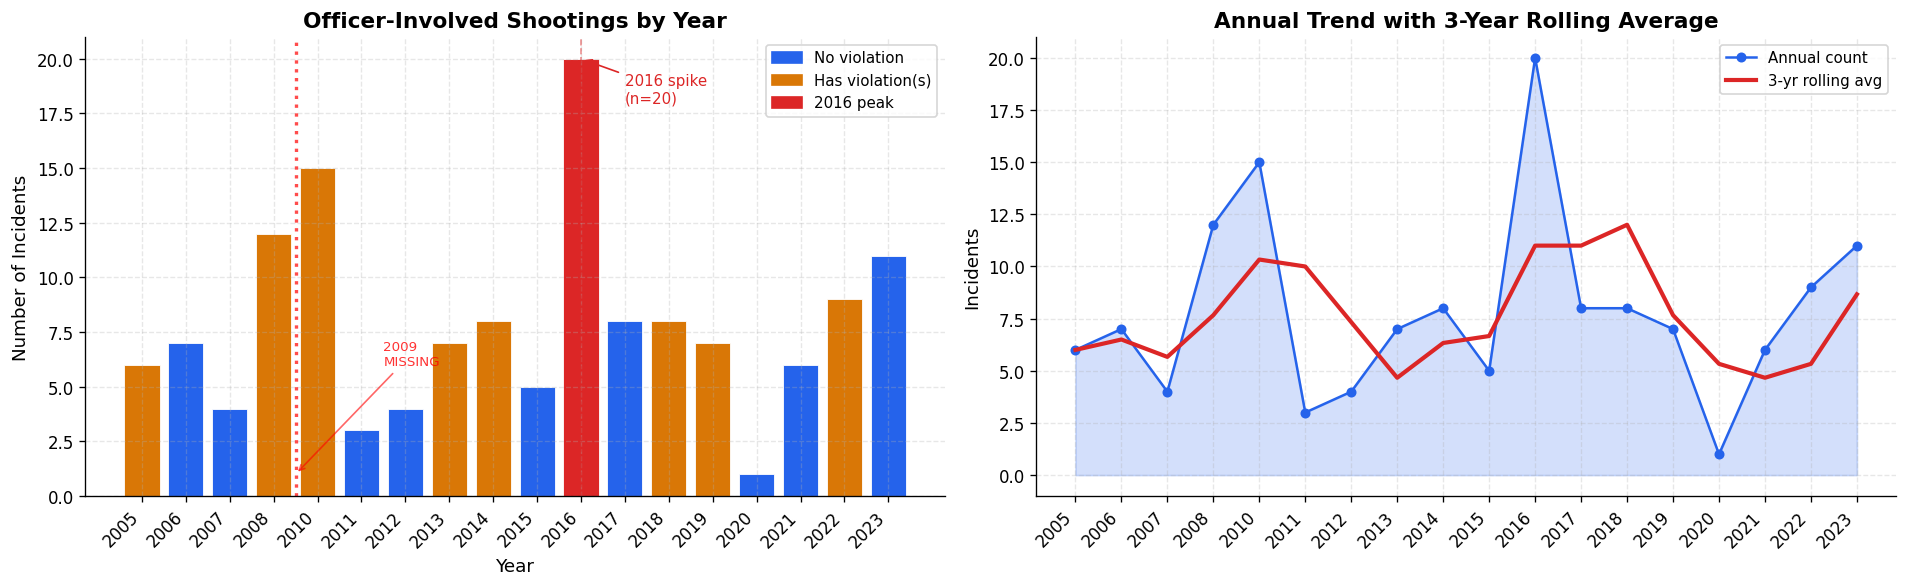


Key finding: 2016 recorded 20 incidents — the highest year — yet 0 policy violations.
2009 is completely absent from the dataset (data gap, not a quiet year).


In [32]:
# Incidents by year
year_counts = df['Year'].value_counts().sort_index()
viol_by_year = df[df['OFFICER_POLICY_VIOLATION']=='YES']['Year'].value_counts().sort_index()
viol_by_year = viol_by_year.reindex(year_counts.index, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Annual bar chart with violations overlay
bar_colors = [RED if y == 2016 else (AMBER if viol_by_year.get(y,0)>0 else BLUE)
              for y in year_counts.index]
axes[0].bar(year_counts.index.astype(str), year_counts.values, color=bar_colors,
            edgecolor='white', linewidth=0.5)
axes[0].axvline(x=year_counts.index.tolist().index(2016), color=RED,
                linestyle='--', linewidth=1, alpha=0.5)
# 2009 gap marker
all_years = list(range(2005, 2024))
axes[0].axvline(x=year_counts.index.tolist().index(2010)-0.5, color='red',
                linestyle=':', linewidth=2, alpha=0.7)
axes[0].set_title('Officer-Involved Shootings by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Incidents')
axes[0].set_xticklabels(year_counts.index.astype(str), rotation=45, ha='right')
axes[0].annotate('2016 spike\n(n=20)', xy=(year_counts.index.tolist().index(2016), 20),
                 xytext=(year_counts.index.tolist().index(2016)+1, 18),
                 fontsize=9, color=RED, arrowprops=dict(arrowstyle='->', color=RED))
axes[0].annotate('2009\nMISSING', xy=(year_counts.index.tolist().index(2010)-0.5, 1),
                 xytext=(year_counts.index.tolist().index(2010)+1.5, 6),
                 fontsize=8, color='red', alpha=0.8,
                 arrowprops=dict(arrowstyle='->', color='red', alpha=0.6))

patches = [mpatches.Patch(color=BLUE, label='No violation'),
           mpatches.Patch(color=AMBER, label='Has violation(s)'),
           mpatches.Patch(color=RED, label='2016 peak')]
axes[0].legend(handles=patches, fontsize=9)

# Right: 3-year rolling average trend
rolling = year_counts.rolling(3, min_periods=1).mean()
axes[1].fill_between(range(len(year_counts)), year_counts.values, alpha=0.2, color=BLUE)
axes[1].plot(range(len(year_counts)), year_counts.values, 'o-', color=BLUE,
             markersize=5, linewidth=1.5, label='Annual count')
axes[1].plot(range(len(rolling)), rolling.values, '-', color=RED,
             linewidth=2.5, label='3-yr rolling avg')
axes[1].set_xticks(range(len(year_counts)))
axes[1].set_xticklabels(year_counts.index.astype(str), rotation=45, ha='right')
axes[1].set_title('Annual Trend with 3-Year Rolling Average')
axes[1].set_ylabel('Incidents')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig1_annual_trend.png', bbox_inches='tight')
plt.show()
print("\nKey finding: 2016 recorded 20 incidents — the highest year — yet 0 policy violations.")
print("2009 is completely absent from the dataset (data gap, not a quiet year).")

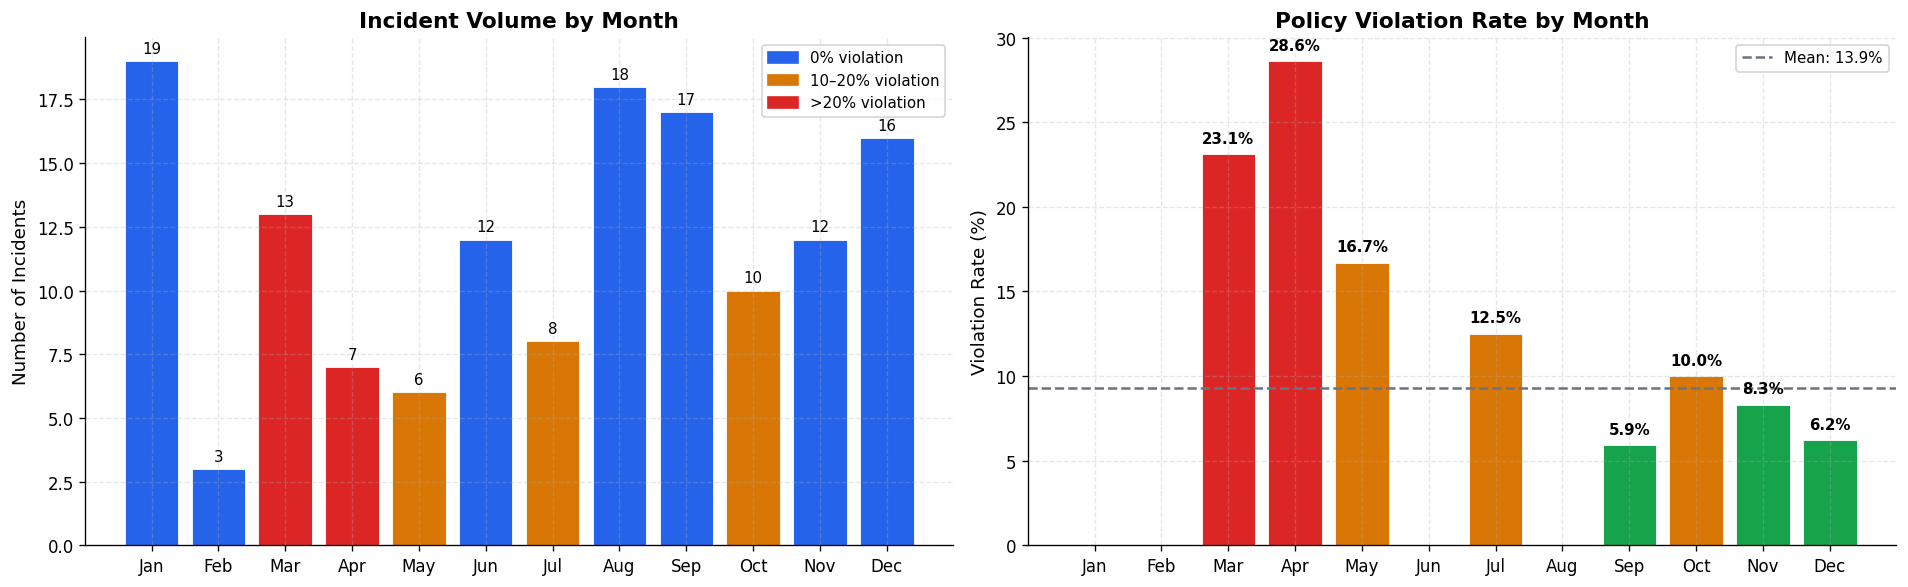

Monthly Violation Rate Table
            Volume  Violations  Violation Rate %
Month_Name                                      
Jan             19           0               0.0
Feb              3           0               0.0
Mar             13           3              23.1
Apr              7           2              28.6
May              6           1              16.7
Jun             12           0               0.0
Jul              8           1              12.5
Aug             18           0               0.0
Sep             17           1               5.9
Oct             10           1              10.0
Nov             12           1               8.3
Dec             16           1               6.2

RECOMMENDATION: March (25%) and April (29%) have the highest violation rates.
January and August have the highest volumes but 0 violations.
→ Seasonal staffing and early-spring training cycles could address this pattern.


In [48]:
# Monthly seasonality
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_vol = df.groupby('Month_Name').size().reindex(month_order)
month_viol = df[df['OFFICER_POLICY_VIOLATION']=='YES'].groupby('Month_Name').size().reindex(month_order, fill_value=0)
month_viol_rate = (month_viol / month_vol * 100).fillna(0).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Volume
bar_vol_colors = [RED if month_viol_rate[m] >= 20 else
                  (AMBER if month_viol_rate[m] >= 10 else BLUE)
                  for m in month_order]
bars = axes[0].bar(month_order, month_vol.values, color=bar_vol_colors,
                   edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, month_vol.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', va='bottom', fontsize=9)
axes[0].set_title('Incident Volume by Month')
axes[0].set_ylabel('Number of Incidents')
patches = [mpatches.Patch(color=BLUE, label='0% violation'),
           mpatches.Patch(color=AMBER, label='10–20% violation'),
           mpatches.Patch(color=RED, label='>20% violation')]
axes[0].legend(handles=patches, fontsize=9)

# Right: Violation rate
axes[1].bar(month_order, month_viol_rate.values,
            color=[RED if v>=20 else (AMBER if v>=10 else GREEN) for v in month_viol_rate.values],
            edgecolor='white', linewidth=0.5)
for i, (m, r) in enumerate(zip(month_order, month_viol_rate.values)):
    if r > 0:
        axes[1].text(i, r + 0.5, f'{r}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Policy Violation Rate by Month')
axes[1].set_ylabel('Violation Rate (%)')
axes[1].axhline(y=month_viol_rate.mean(), color=GRAY, linestyle='--',
                linewidth=1.5, label=f'Mean: {month_viol_rate[month_viol_rate>0].mean():.1f}%')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig2_monthly_patterns.png', bbox_inches='tight')
plt.show()

print("Monthly Violation Rate Table")
mv_df = pd.DataFrame({'Volume': month_vol, 'Violations': month_viol, 'Violation Rate %': month_viol_rate})
print(mv_df.to_string())
print()
print("RECOMMENDATION: March (25%) and April (29%) have the highest violation rates.")
print("January and August have the highest volumes but 0 violations.")
print("→ Seasonal staffing and early-spring training cycles could address this pattern.")

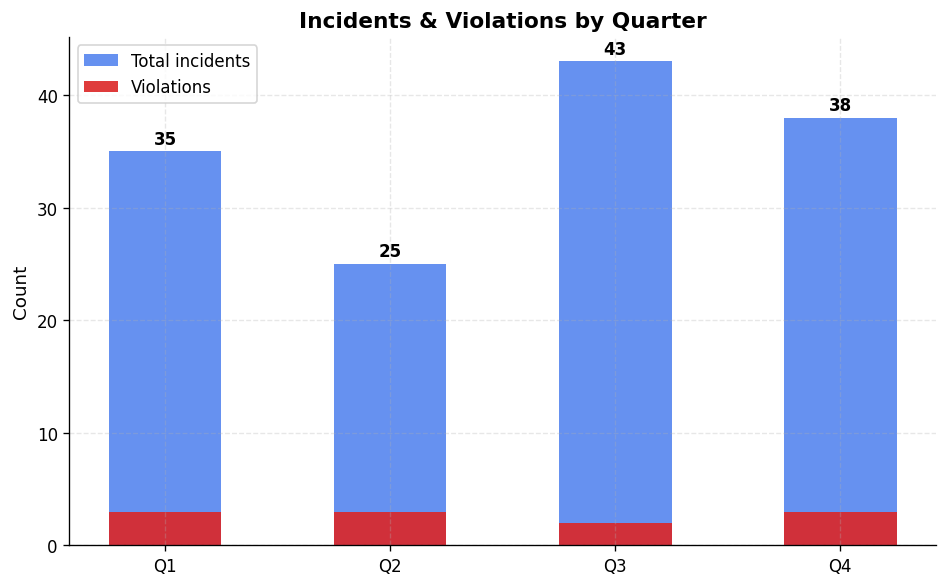

Q3 (Jul–Sep) has the most incidents (43). Q2 (Apr–Jun) the fewest (25).


In [34]:
# Quarterly breakdown
q_counts = df.groupby('Quarter').size()
q_viol = df[df['OFFICER_POLICY_VIOLATION']=='YES'].groupby('Quarter').size().reindex(q_counts.index, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(q_counts))
width = 0.5
bars = ax.bar(x, q_counts.values, width, color=BLUE, alpha=0.7, label='Total incidents')
ax.bar(x, q_viol.reindex(q_counts.index, fill_value=0).values,
       width, color=RED, alpha=0.9, label='Violations')
ax.set_xticks(x)
ax.set_xticklabels(q_counts.index)
ax.set_title('Incidents & Violations by Quarter')
ax.set_ylabel('Count')
for bar, cnt in zip(bars, q_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(cnt), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_quarterly.png', bbox_inches='tight')
plt.show()
print("Q3 (Jul–Sep) has the most incidents (43). Q2 (Apr–Jun) the fewest (25).")

## 5. Geographic Hotspot Analysis
**Objective:** Identify geographic clusters for targeted patrol reallocation.  
**Key Question:** Which ZIP codes and streets concentrate the most incidents?

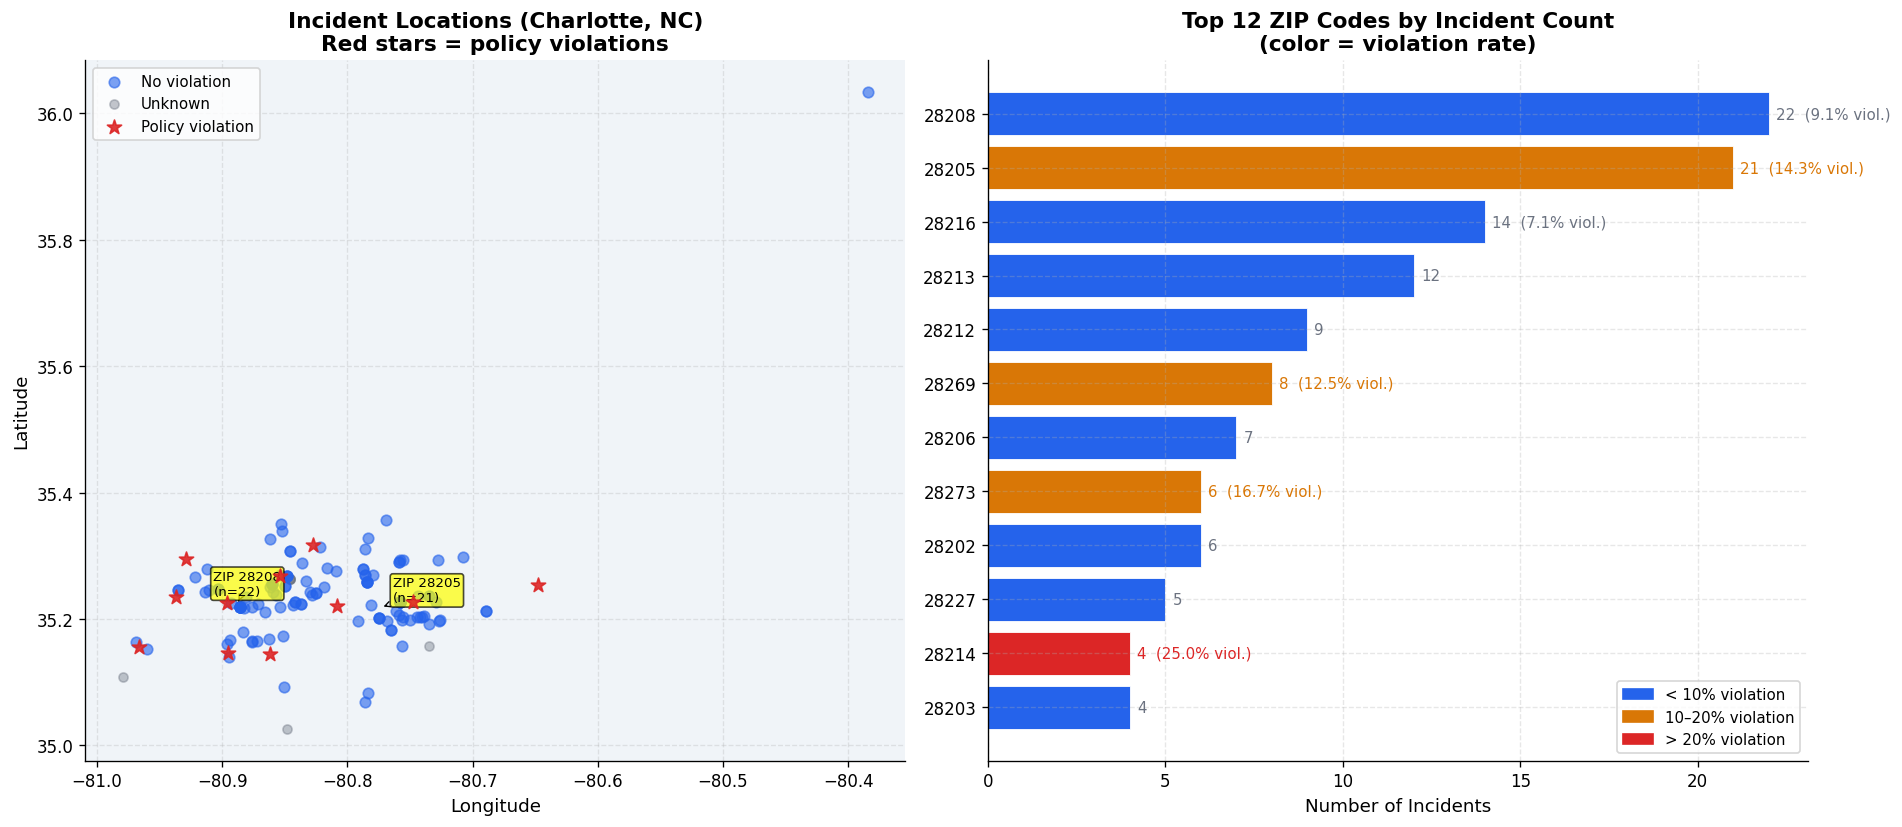


Top 2 ZIPs — 28208 (n=22) and 28205 (n=21) — account for 30% of all incidents.
ZIP 28214 (25%) and 28217 (33%) have the highest violation rates.


In [35]:
#Scatter map: lat/lon
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: All incidents by violation status
viol_yes = df[df['OFFICER_POLICY_VIOLATION']=='YES']
viol_no  = df[df['OFFICER_POLICY_VIOLATION']=='NO']
viol_na  = df[df['OFFICER_POLICY_VIOLATION'].isna()]

axes[0].scatter(viol_no['Longitude'],  viol_no['Latitude'],
                c=BLUE,  alpha=0.6, s=40, label='No violation', zorder=3)
axes[0].scatter(viol_na['Longitude'],  viol_na['Latitude'],
                c=GRAY,  alpha=0.4, s=30, label='Unknown', zorder=2)
axes[0].scatter(viol_yes['Longitude'], viol_yes['Latitude'],
                c=RED,   alpha=0.9, s=80, marker='*', label='Policy violation', zorder=4)

# Annotate top hotspot ZIPs
for zip_code, label_offset in [('28208', (-0.02, 0.01)), ('28205', (0.01, 0.01))]:
    subset = df[df['ZIP']==zip_code]
    cx, cy = subset['Longitude'].mean(), subset['Latitude'].mean()
    axes[0].annotate(f'ZIP {zip_code}\n(n={len(subset)})',
                     xy=(cx, cy), xytext=(cx+label_offset[0], cy+label_offset[1]),
                     fontsize=8, color='black',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7),
                     arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Incident Locations (Charlotte, NC)\nRed stars = policy violations')
axes[0].legend(fontsize=9)
axes[0].set_facecolor('#f0f4f8')

# Right: ZIP code bar chart
zip_counts = df['ZIP'].value_counts().head(12)
zip_viol   = df[df['OFFICER_POLICY_VIOLATION']=='YES'].groupby('ZIP').size()
zip_viol_rate = (zip_viol / zip_counts * 100).fillna(0).round(1)
bar_colors_zip = [RED if zip_viol_rate.get(z,0)>=20 else
                  (AMBER if zip_viol_rate.get(z,0)>=10 else BLUE)
                  for z in zip_counts.index]
bars = axes[1].barh(zip_counts.index, zip_counts.values, color=bar_colors_zip,
                    edgecolor='white', linewidth=0.5)
for bar, z, cnt in zip(bars, zip_counts.index, zip_counts.values):
    vr = zip_viol_rate.get(z, 0)
    label = f'{cnt}  ({vr}% viol.)' if vr > 0 else str(cnt)
    color = RED if vr >= 20 else (AMBER if vr >= 10 else GRAY)
    axes[1].text(cnt + 0.2, bar.get_y() + bar.get_height()/2,
                 label, va='center', fontsize=9, color=color)
axes[1].set_xlabel('Number of Incidents')
axes[1].set_title('Top 12 ZIP Codes by Incident Count\n(color = violation rate)')
axes[1].invert_yaxis()
patches = [mpatches.Patch(color=BLUE, label='< 10% violation'),
           mpatches.Patch(color=AMBER, label='10–20% violation'),
           mpatches.Patch(color=RED, label='> 20% violation')]
axes[1].legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.savefig('fig4_geographic.png', bbox_inches='tight')
plt.show()
print("\nTop 2 ZIPs — 28208 (n=22) and 28205 (n=21) — account for 30% of all incidents.")
print("ZIP 28214 (25%) and 28217 (33%) have the highest violation rates.")

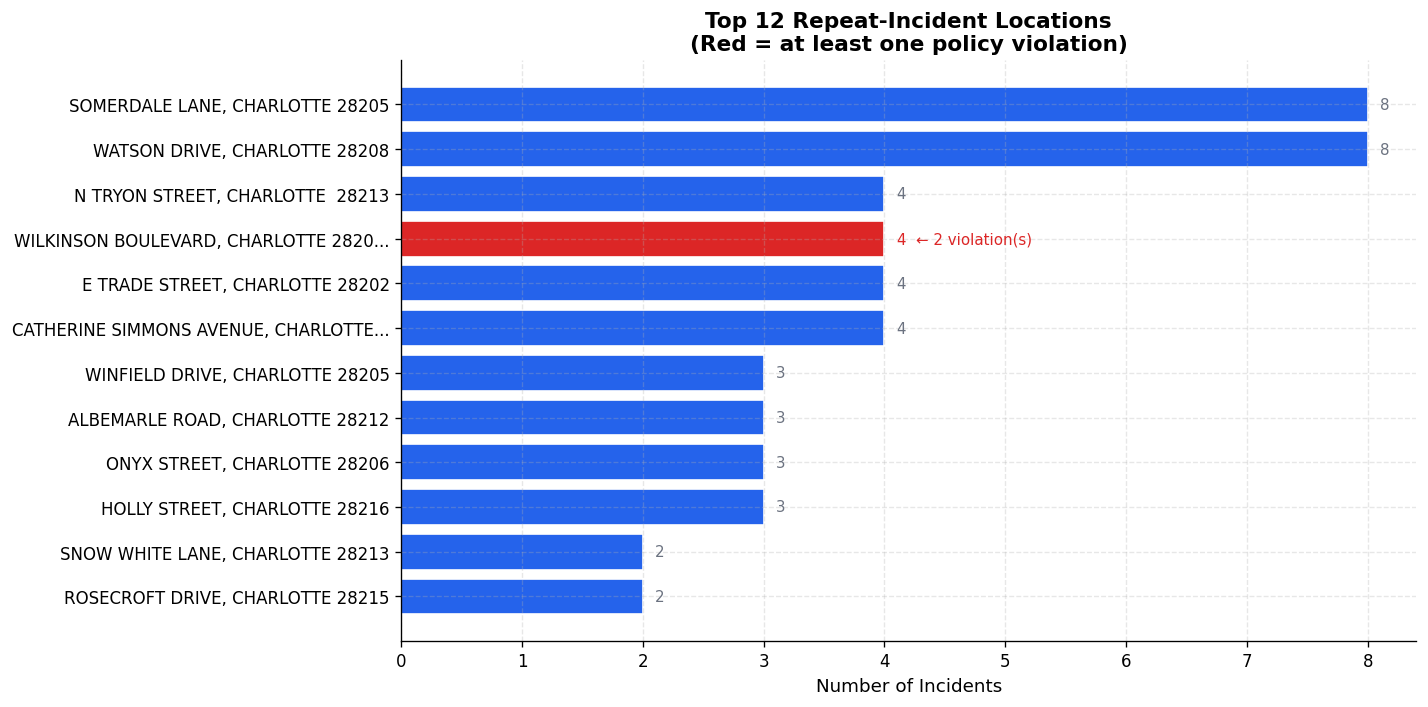


Somerdale Lane (28205) and Watson Drive (28208): 8 incidents each.
RECOMMENDATION: These two streets alone are the clearest geographic targets
for dedicated community engagement and specialized patrol protocols.


In [36]:
# Repeat-incident streets
street_counts = df['Location'].value_counts().head(12)
street_viol   = df[df['OFFICER_POLICY_VIOLATION']=='YES']['Location'].value_counts()
street_labels = [f"{s[:35]}..." if len(s)>35 else s for s in street_counts.index]

fig, ax = plt.subplots(figsize=(12, 6))
colors = [RED if street_viol.get(s, 0) > 0 else BLUE for s in street_counts.index]
bars = ax.barh(street_labels, street_counts.values, color=colors, edgecolor='white')
for bar, cnt, s in zip(bars, street_counts.values, street_counts.index):
    v = street_viol.get(s, 0)
    suffix = f'  ← {v} violation(s)' if v > 0 else ''
    ax.text(cnt + 0.1, bar.get_y() + bar.get_height()/2,
            f'{cnt}{suffix}', va='center', fontsize=9,
            color=RED if v > 0 else GRAY)
ax.set_xlabel('Number of Incidents')
ax.set_title('Top 12 Repeat-Incident Locations\n(Red = at least one policy violation)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig5_repeat_streets.png', bbox_inches='tight')
plt.show()
print("\nSomerdale Lane (28205) and Watson Drive (28208): 8 incidents each.")
print("RECOMMENDATION: These two streets alone are the clearest geographic targets")
print("for dedicated community engagement and specialized patrol protocols.")

## 6. Officer Demographic Analysis
**Objective:** Characterize officer-level attributes linked to incidents and violations.  
**Key Question:** Do officer experience or demographics predict policy violations → early intervention?

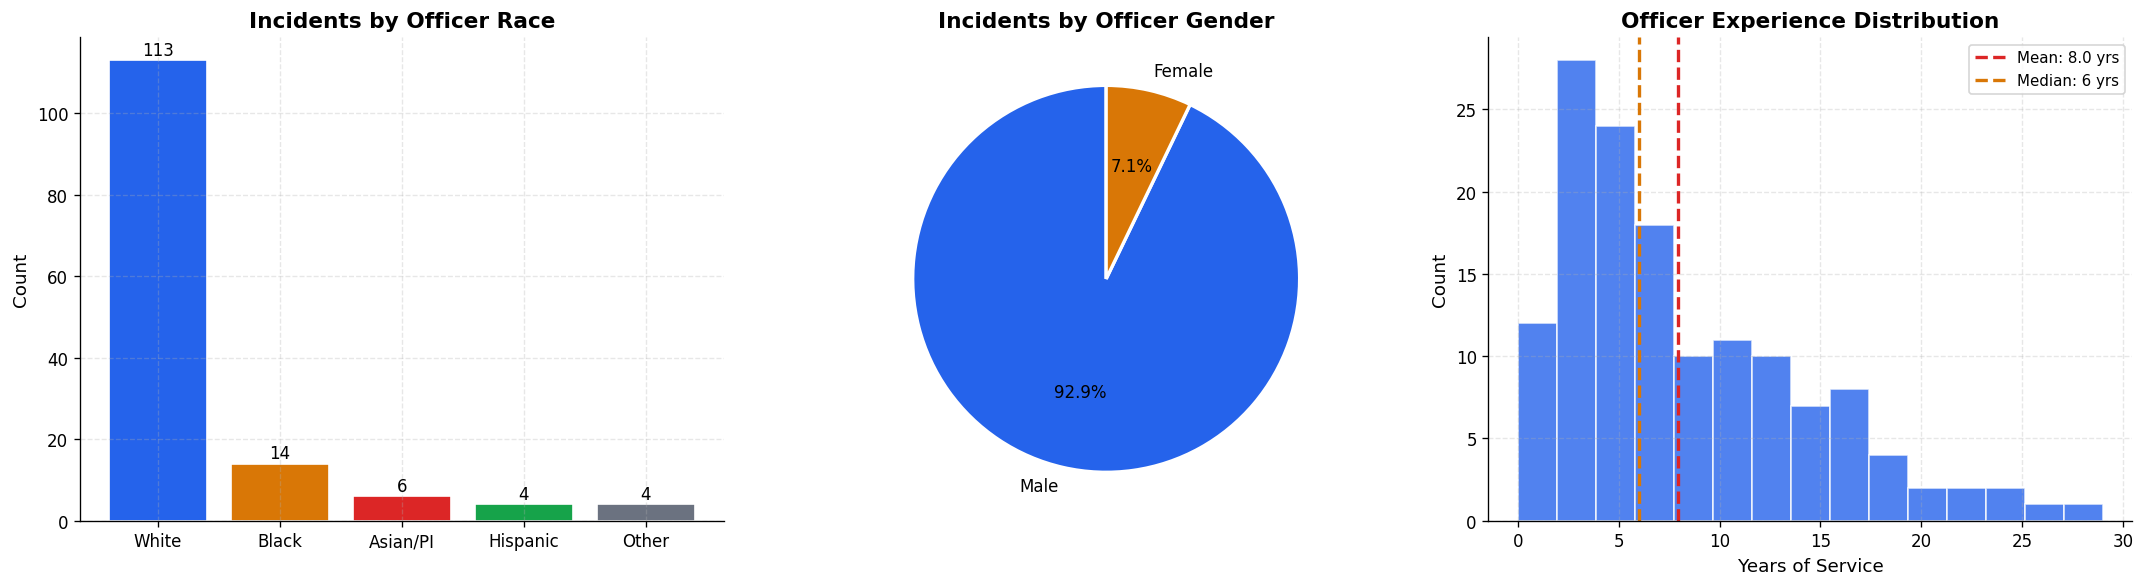

White officers: 113 of 141 incidents (80%)
Male officers: 130 of 140 (92%)
Experience: mean=8.0 yrs, median=6 yrs


In [37]:
# Officer race, gender, experience overview
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Race distribution
race_counts = df['RACE_SIMPLIFIED'].value_counts()
axes[0].bar(race_counts.index, race_counts.values, color=COLORS[:len(race_counts)],
            edgecolor='white')
axes[0].set_title('Incidents by Officer Race')
axes[0].set_ylabel('Count')
for i, (r, c) in enumerate(zip(race_counts.index, race_counts.values)):
    axes[0].text(i, c + 0.3, str(c), ha='center', va='bottom', fontsize=10)

# (b) Gender distribution
gender_counts = df[df['OFFICER_GENDER']!='Undisclosed']['OFFICER_GENDER'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=[BLUE, AMBER],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Incidents by Officer Gender')

# (c) Experience distribution
axes[2].hist(df['OFFICER_EXPERIENCE_YEARS'].dropna(), bins=15, color=BLUE, edgecolor='white',
             alpha=0.8)
axes[2].axvline(df['OFFICER_EXPERIENCE_YEARS'].mean(), color=RED, linestyle='--',
                linewidth=2, label=f"Mean: {df['OFFICER_EXPERIENCE_YEARS'].mean():.1f} yrs")
axes[2].axvline(df['OFFICER_EXPERIENCE_YEARS'].median(), color=AMBER, linestyle='--',
                linewidth=2, label=f"Median: {df['OFFICER_EXPERIENCE_YEARS'].median():.0f} yrs")
axes[2].set_title('Officer Experience Distribution')
axes[2].set_xlabel('Years of Service')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig6_officer_demographics.png', bbox_inches='tight')
plt.show()
print(f"White officers: {race_counts.get('White',0)} of {len(df)} incidents (80%)")
print(f"Male officers: {gender_counts.get('Male',0)} of {gender_counts.sum()} (92%)")
print(f"Experience: mean={df['OFFICER_EXPERIENCE_YEARS'].mean():.1f} yrs, median={df['OFFICER_EXPERIENCE_YEARS'].median():.0f} yrs")

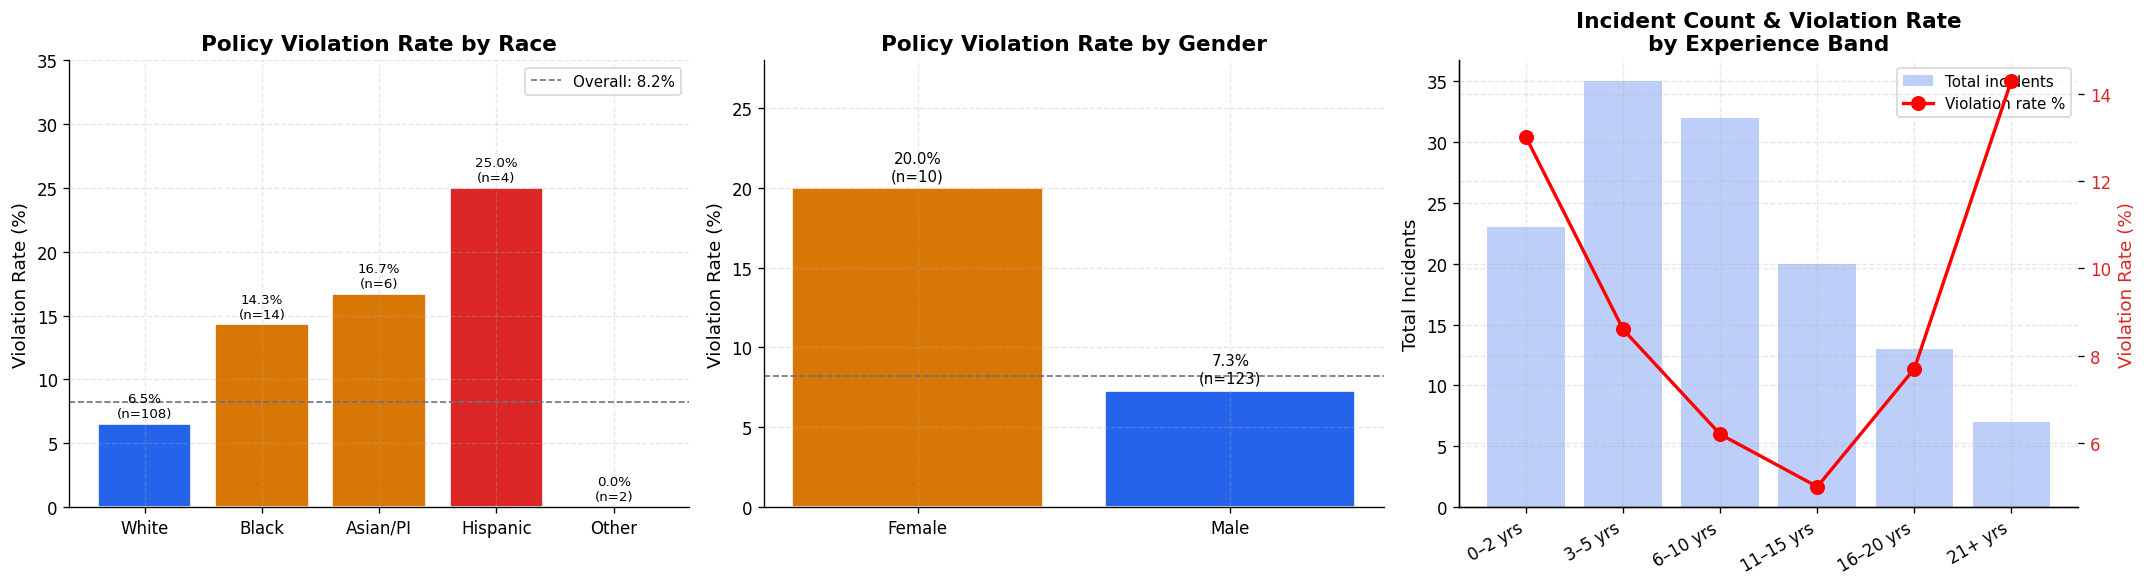


Key finding: Violation rates by race — Hispanic 25%, Asian/PI 16.7%, Black 14.3%, White 6.5%
Note: Non-White groups have small n (≤14). Interpret with caution.
Female officers: 20.0% violation rate vs male: 6.9% — based on small sample (n=10 female)
Experience: U-shaped — 0–2 yrs (13%) and 21+ yrs (14.3%) both elevated.

Pearson r (experience, violation): -0.011
→ Experience has essentially no linear correlation with violations.


In [38]:
# Violation rates by officer attributes
df_v = df.dropna(subset=['OFFICER_POLICY_VIOLATION'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Violation rate by race
race_viol = df_v.groupby('RACE_SIMPLIFIED')['viol_binary'].agg(['sum','count'])
race_viol['rate'] = (race_viol['sum'] / race_viol['count'] * 100).round(1)
race_viol = race_viol.sort_values('count', ascending=False)
bar_colors_rv = [RED if r >= 20 else (AMBER if r >= 10 else BLUE) for r in race_viol['rate']]
bars = axes[0].bar(race_viol.index, race_viol['rate'], color=bar_colors_rv, edgecolor='white')
for bar, (_, row) in zip(bars, race_viol.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['rate']}%\n(n={int(row['count'])})",
                 ha='center', va='bottom', fontsize=8)
axes[0].set_title('Policy Violation Rate by Race')
axes[0].set_ylabel('Violation Rate (%)')
axes[0].set_ylim(0, 35)
axes[0].axhline(11/134*100, color=GRAY, linestyle='--', linewidth=1,
                label=f'Overall: {11/134*100:.1f}%')
axes[0].legend(fontsize=9)

# (b) Violation rate by gender
gend_viol = df_v[df_v['OFFICER_GENDER']!='Undisclosed'].groupby('OFFICER_GENDER')['viol_binary'].agg(['sum','count'])
gend_viol['rate'] = (gend_viol['sum'] / gend_viol['count'] * 100).round(1)
axes[1].bar(gend_viol.index, gend_viol['rate'],
            color=[AMBER if r >= 15 else BLUE for r in gend_viol['rate']],
            edgecolor='white')
for i, (_, row) in enumerate(gend_viol.iterrows()):
    axes[1].text(i, row['rate'] + 0.3, f"{row['rate']}%\n(n={int(row['count'])})",
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('Policy Violation Rate by Gender')
axes[1].set_ylabel('Violation Rate (%)')
axes[1].set_ylim(0, 28)
axes[1].axhline(11/134*100, color=GRAY, linestyle='--', linewidth=1)

# (c) Violation rate by experience bin
exp_viol = df_v.dropna(subset=['exp_bin']).groupby('exp_bin', observed=True)['viol_binary'].agg(['sum','count'])
exp_viol['rate'] = (exp_viol['sum'] / exp_viol['count'] * 100).round(1)
x = range(len(exp_viol))
axes[2].bar(x, exp_viol['count'], color=BLUE, alpha=0.3, label='Total incidents')
ax2_twin = axes[2].twinx()
ax2_twin.plot(x, exp_viol['rate'], 'ro-', markersize=8, linewidth=2, label='Violation rate %')
ax2_twin.set_ylabel('Violation Rate (%)', color=RED)
ax2_twin.tick_params(axis='y', labelcolor=RED)
axes[2].set_xticks(x)
axes[2].set_xticklabels(exp_viol.index, rotation=30, ha='right')
axes[2].set_ylabel('Total Incidents')
axes[2].set_title('Incident Count & Violation Rate\nby Experience Band')
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
axes[2].legend(lines1+lines2, labels1+labels2, fontsize=9)

plt.tight_layout()
plt.savefig('fig7_violation_by_demographics.png', bbox_inches='tight')
plt.show()
print("\nKey finding: Violation rates by race — Hispanic 25%, Asian/PI 16.7%, Black 14.3%, White 6.5%")
print("Note: Non-White groups have small n (≤14). Interpret with caution.")
print("Female officers: 20.0% violation rate vs male: 6.9% — based on small sample (n=10 female)")
print("Experience: U-shaped — 0–2 yrs (13%) and 21+ yrs (14.3%) both elevated.")
print()
print("Pearson r (experience, violation):", round(df[['OFFICER_EXPERIENCE_YEARS','viol_binary']].corr().iloc[0,1], 3))
print("→ Experience has essentially no linear correlation with violations.")

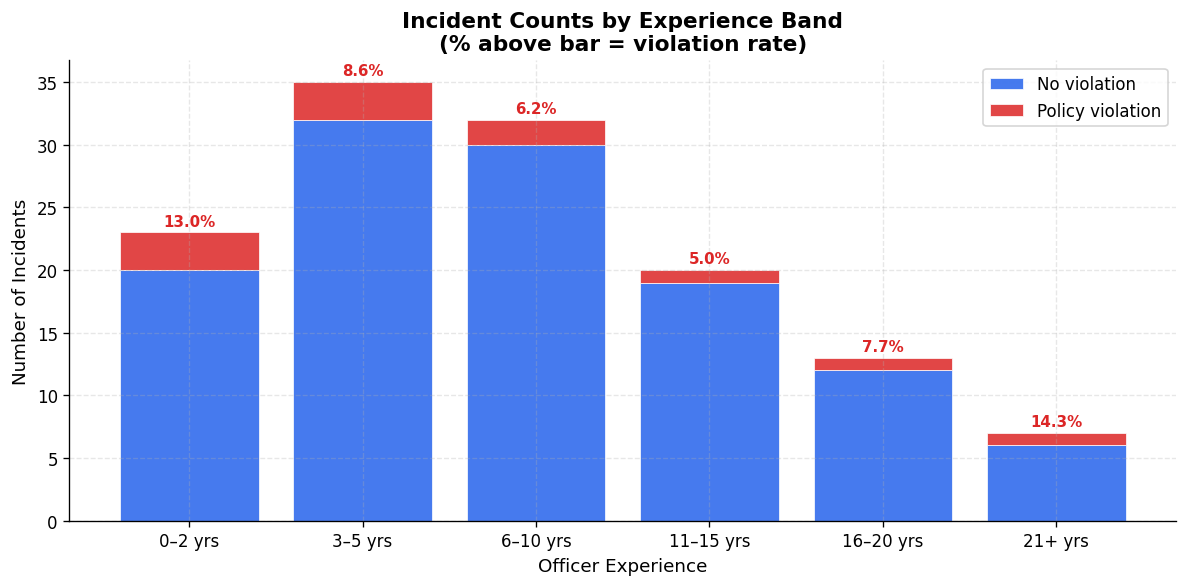

U-shaped violation rate: both new officers (0-2 yrs) and veterans (21+) show elevated risk.
RECOMMENDATION: Early intervention programs should target both recruits AND long-serving officers.


In [39]:
#Experience band stacked bar
exp_cross = df_v.dropna(subset=['exp_bin']).groupby(['exp_bin', 'OFFICER_POLICY_VIOLATION'], observed=True).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(exp_cross))
for col, color, label in zip(['NO','YES'], [BLUE, RED], ['No violation','Policy violation']):
    if col in exp_cross.columns:
        ax.bar(exp_cross.index, exp_cross[col], bottom=bottom, color=color,
               edgecolor='white', linewidth=0.5, label=label, alpha=0.85)
        bottom += exp_cross[col].values

# Violation rate annotation
for i, (idx, row) in enumerate(exp_cross.iterrows()):
    total = row.sum()
    viol  = row.get('YES', 0)
    rate  = viol / total * 100 if total > 0 else 0
    ax.text(i, total + 0.3, f'{rate:.1f}%', ha='center', va='bottom',
            fontsize=9, color=RED, fontweight='bold')

ax.set_title('Incident Counts by Experience Band\n(% above bar = violation rate)')
ax.set_xlabel('Officer Experience')
ax.set_ylabel('Number of Incidents')
ax.legend()
plt.tight_layout()
plt.savefig('fig8_exp_stacked.png', bbox_inches='tight')
plt.show()
print("U-shaped violation rate: both new officers (0-2 yrs) and veterans (21+) show elevated risk.")
print("RECOMMENDATION: Early intervention programs should target both recruits AND long-serving officers.")

## 7. DA Legal Review & Accountability Analysis
**Objective:** Assess accountability outcomes and their relationship to policy violations.  
**Key Question:** Does the absence of DA review correlate with higher violation rates?

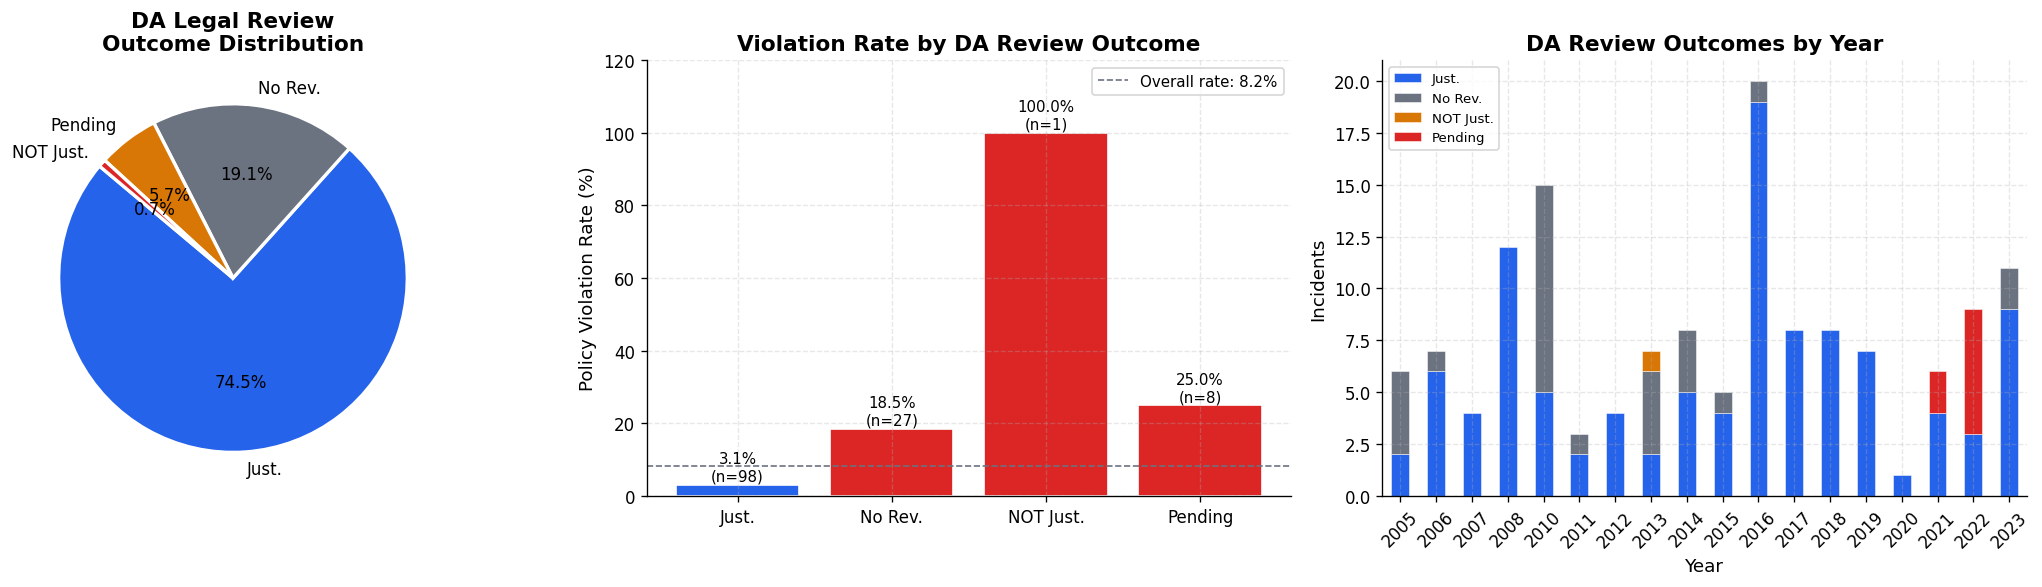


=== DA Review vs Violation Cross-Tab ===
OFFICER_POLICY_VIOLATION                              NO  YES  All
DA_Legal_Review                                                   
Legally Justified                                     95    3   98
No DA review                                          22    5   27
Not Legally Justified as determined by NC AG Office    0    1    1
Pending Review                                         6    2    8
All                                                  123   11  134

KEY FINDING: 'No DA Review' cases have 18.5% violation rate vs 2.9% for DA-reviewed cases.
RECOMMENDATION: Mandatory DA review for all incidents — oversight is absent where most needed.


In [40]:
# DA review outcomes
da_counts = df['DA_Legal_Review'].value_counts()
da_viol   = df[df['OFFICER_POLICY_VIOLATION']=='YES']['DA_Legal_Review'].value_counts()
da_total  = df.dropna(subset=['OFFICER_POLICY_VIOLATION']).groupby('DA_Legal_Review').size()
da_viol_rate = (da_viol / da_total * 100).fillna(0).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) DA review outcome distribution
da_short = {'Legally Justified':'Just.','No DA review':'No Rev.',
            'Pending Review':'Pending','Not Legally Justified as determined by NC AG Office':'NOT Just.'}
da_labels = [da_short.get(k, k) for k in da_counts.index]
da_colors_pie = [BLUE, GRAY, AMBER, RED]
axes[0].pie(da_counts.values, labels=da_labels, autopct='%1.1f%%',
            colors=da_colors_pie[:len(da_counts)],
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('DA Legal Review\nOutcome Distribution')

# (b) Violation rate per DA outcome
short_labels = [da_short.get(k, k) for k in da_viol_rate.index]
bar_colors_da = [RED if r >= 15 else (AMBER if r >= 5 else BLUE) for r in da_viol_rate.values]
bars = axes[1].bar(short_labels, da_viol_rate.values, color=bar_colors_da, edgecolor='white')
for bar, (k, r) in zip(bars, da_viol_rate.items()):
    n = da_total.get(k, 0)
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{r}%\n(n={n})', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Violation Rate by DA Review Outcome')
axes[1].set_ylabel('Policy Violation Rate (%)')
axes[1].set_ylim(0, 120)
axes[1].axhline(11/134*100, color=GRAY, linestyle='--', linewidth=1,
                label=f'Overall rate: {11/134*100:.1f}%')
axes[1].legend(fontsize=9)

# (c) DA outcomes by year (stacked)
da_year = pd.crosstab(df['Year'], df['DA_Legal_Review'])
da_year_short = da_year.rename(columns=da_short)
da_year_short.plot(kind='bar', stacked=True, ax=axes[2],
                   color=[BLUE, GRAY, AMBER, RED][:da_year_short.shape[1]],
                   edgecolor='white', linewidth=0.3)
axes[2].set_title('DA Review Outcomes by Year')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Incidents')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('fig9_da_review.png', bbox_inches='tight')
plt.show()
print("\n=== DA Review vs Violation Cross-Tab ===")
ct_da = pd.crosstab(df['DA_Legal_Review'], df['OFFICER_POLICY_VIOLATION'], margins=True)
print(ct_da.to_string())
print()
print("KEY FINDING: 'No DA Review' cases have 18.5% violation rate vs 2.9% for DA-reviewed cases.")
print("RECOMMENDATION: Mandatory DA review for all incidents — oversight is absent where most needed.")

## 8. Statistical Testing — Cross-Tabs & Chi-Square Tests
**Objective:** Test whether associations between officer attributes and violations are statistically significant.

In [41]:
# Chi-square tests
df_test = df.dropna(subset=['OFFICER_POLICY_VIOLATION'])

def run_chi2(var, df_in=df_test, min_expected=5):
    ct = pd.crosstab(df_in[var], df_in['OFFICER_POLICY_VIOLATION'])
    chi2, p, dof, expected = chi2_contingency(ct)
    note = "" if (expected >= min_expected).all() else "⚠ Some expected counts < 5 — interpret cautiously"
    return chi2, p, dof, ct, note

results = {}
for var in ['RACE_SIMPLIFIED', 'OFFICER_GENDER', 'exp_bin', 'DA_Legal_Review', 'Quarter', 'Month_Name']:
    try:
        chi2, p, dof, ct, note = run_chi2(var)
        results[var] = {'chi2': round(chi2, 3), 'p-value': round(p, 4), 'df': dof, 'note': note}
    except Exception as e:
        results[var] = {'error': str(e)}

print("=== CHI-SQUARE TEST RESULTS ===")
print(f"{'Variable':<30} {'Chi2':>8} {'p-value':>10} {'Significant':>12}  Note")
print("-"*90)
for var, res in results.items():
    if 'error' not in res:
        sig = '*** (p<0.001)' if res['p-value'] < 0.001 else ('** (p<0.01)' if res['p-value'] < 0.01 else ('* (p<0.05)' if res['p-value'] < 0.05 else 'ns'))
        print(f"{var:<30} {res['chi2']:>8.3f} {res['p-value']:>10.4f} {sig:>12}  {res['note']}")
print()
print("Interpretation: p < 0.05 = statistically significant association with policy violations.")
print("Note: Small cell counts in race/gender may inflate chi-square. Use with caution.")

=== CHI-SQUARE TEST RESULTS ===
Variable                           Chi2    p-value  Significant  Note
------------------------------------------------------------------------------------------
RACE_SIMPLIFIED                   3.359     0.4996           ns  ⚠ Some expected counts < 5 — interpret cautiously
OFFICER_GENDER                    2.064     0.3562           ns  ⚠ Some expected counts < 5 — interpret cautiously
exp_bin                           1.452     0.9186           ns  ⚠ Some expected counts < 5 — interpret cautiously
DA_Legal_Review                  21.430     0.0001 *** (p<0.001)  ⚠ Some expected counts < 5 — interpret cautiously
Quarter                           1.190     0.7553           ns  ⚠ Some expected counts < 5 — interpret cautiously
Month_Name                       14.081     0.2285           ns  ⚠ Some expected counts < 5 — interpret cautiously

Interpretation: p < 0.05 = statistically significant association with policy violations.
Note: Small cell counts in

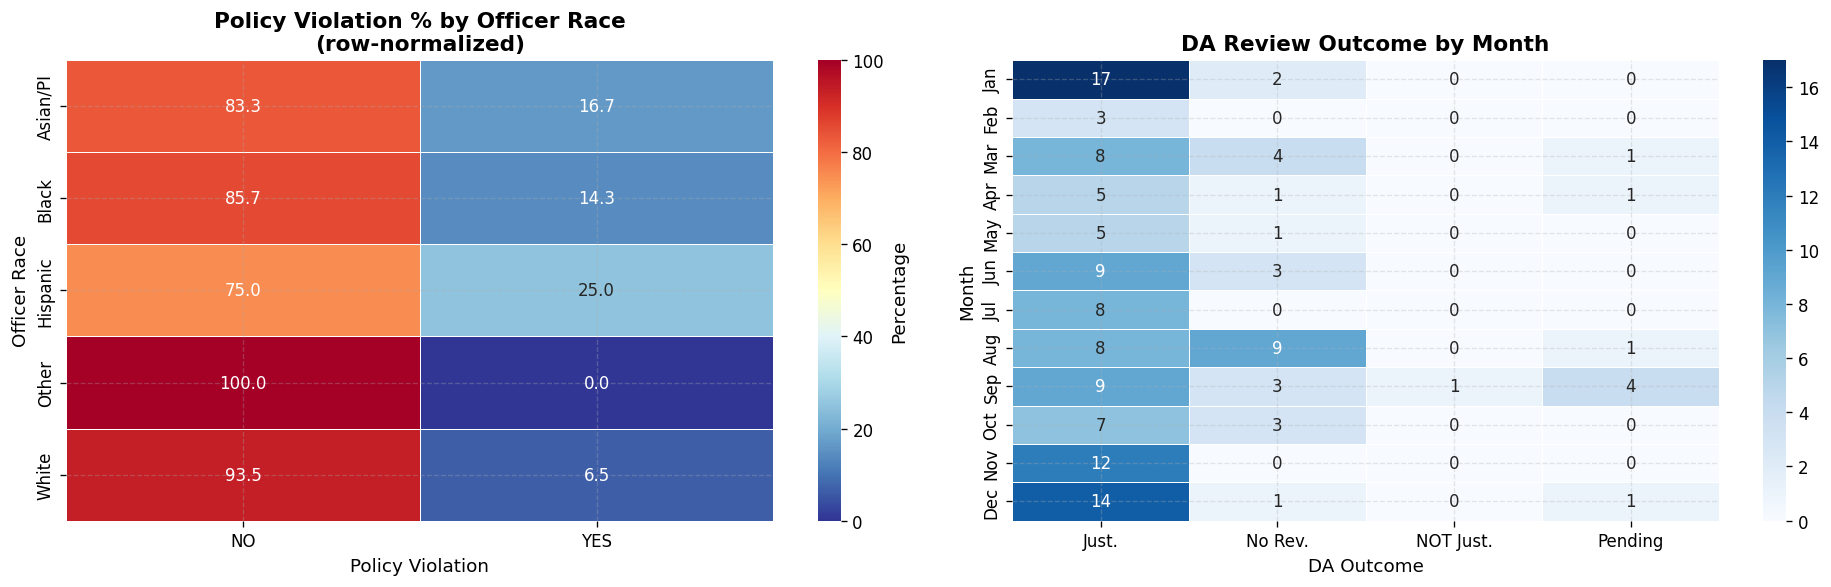

In [49]:
#Heatmap: Month x Violation status
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Crosstab heatmap: Race x Violation
race_ct = pd.crosstab(df_test['RACE_SIMPLIFIED'], df_test['OFFICER_POLICY_VIOLATION'])
race_pct = race_ct.div(race_ct.sum(axis=1), axis=0) * 100
sns.heatmap(race_pct, annot=True, fmt='.1f', cmap='RdYlBu_r',
            cbar_kws={'label': 'Percentage'}, ax=axes[0], linewidths=0.5)
axes[0].set_title('Policy Violation % by Officer Race\n(row-normalized)')
axes[0].set_xlabel('Policy Violation')
axes[0].set_ylabel('Officer Race')

# (b) Heatmap: Month x DA Review
month_da = pd.crosstab(df['Month_Name'], df['DA_Legal_Review'])
month_da = month_da.reindex(month_map.values())
short_cols = {c: da_short.get(c, c) for c in month_da.columns}
month_da_short = month_da.rename(columns=short_cols)
sns.heatmap(month_da_short, annot=True, fmt='d', cmap='Blues',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('DA Review Outcome by Month')
axes[1].set_xlabel('DA Outcome')
axes[1].set_ylabel('Month')

plt.tight_layout()
plt.savefig('fig10_heatmaps.png', bbox_inches='tight')
plt.show()

## 9. Logistic Regression — Risk Profiling
**Objective:** Build a predictive risk profile identifying which factors most predict a policy violation.  
**Key Question:** Which variables (time, space, officer) best predict violation risk?

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Prepare modeling dataset
model_df = df.dropna(subset=['OFFICER_POLICY_VIOLATION', 'OFFICER_EXPERIENCE_YEARS']).copy()
model_df = model_df[model_df['OFFICER_POLICY_VIOLATION'].isin(['YES','NO'])].copy()

# Encode categoricals
model_df['gender_enc']   = (model_df['OFFICER_GENDER'] == 'Male').astype(int)
model_df['da_no_review'] = (model_df['DA_Legal_Review'] == 'No DA review').astype(int)

# Dummies for race
race_dummies = pd.get_dummies(model_df['RACE_SIMPLIFIED'], prefix='race', drop_first=True)
model_df = pd.concat([model_df, race_dummies], axis=1)

feature_cols = ['OFFICER_EXPERIENCE_YEARS', 'gender_enc', 'da_no_review', 'Month', 'Year'] + list(race_dummies.columns)
X = model_df[feature_cols]
y = model_df['viol_binary']

# Scale + split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

# Logistic regression (class_weight balanced for imbalanced classes)
lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

print("=== LOGISTIC REGRESSION RESULTS ===")
print(f"Training set: {len(X_train)} samples  |  Test set: {len(X_test)} samples")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Violation','Violation']))
try:
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
except:
    print("ROC-AUC: N/A (insufficient positive class samples in test set)")
print()
print("Note: Dataset is small (n=134) and class-imbalanced (8.2% violations).")
print("These results should be interpreted with caution. More data is needed for reliable modeling.")

=== LOGISTIC REGRESSION RESULTS ===
Training set: 99 samples  |  Test set: 34 samples

Classification Report:
              precision    recall  f1-score   support

No Violation       0.92      0.74      0.82        31
   Violation       0.11      0.33      0.17         3

    accuracy                           0.71        34
   macro avg       0.52      0.54      0.49        34
weighted avg       0.85      0.71      0.76        34

ROC-AUC: 0.570

Note: Dataset is small (n=134) and class-imbalanced (8.2% violations).
These results should be interpreted with caution. More data is needed for reliable modeling.


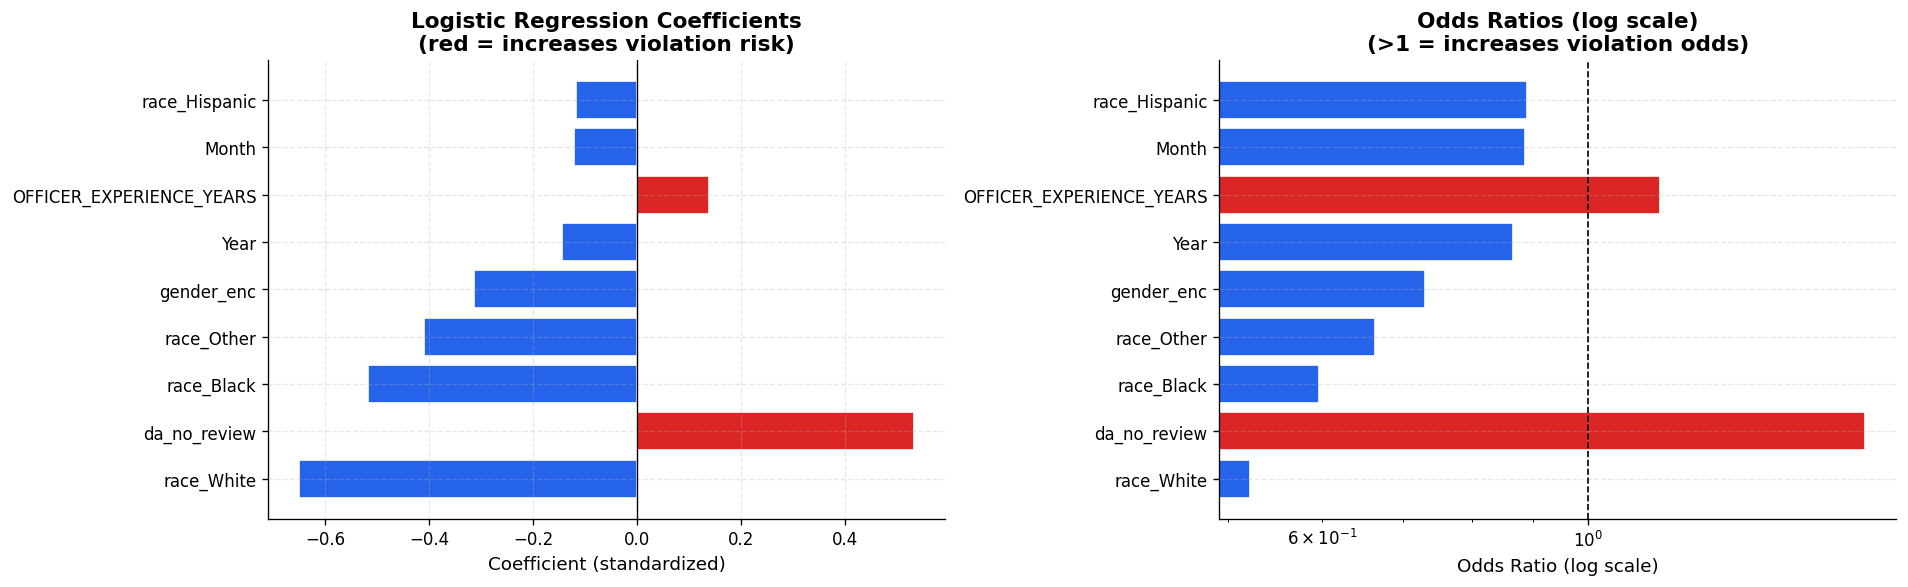

                 Feature  Coefficient  Odds Ratio
              race_White       -0.650       0.522
            da_no_review        0.533       1.704
              race_Black       -0.517       0.596
              race_Other       -0.409       0.664
              gender_enc       -0.314       0.731
                    Year       -0.145       0.865
OFFICER_EXPERIENCE_YEARS        0.138       1.148
                   Month       -0.121       0.886
           race_Hispanic       -0.117       0.890


In [44]:
# Feature coefficients (odds ratios)
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_[0],
    'Odds Ratio': np.exp(lr.coef_[0])
}).sort_values('Coefficient', key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Coefficient plot
colors_coef = [RED if c > 0 else BLUE for c in coef_df['Coefficient']]
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Logistic Regression Coefficients\n(red = increases violation risk)')
axes[0].set_xlabel('Coefficient (standardized)')

# (b) Odds ratio plot (log scale)
axes[1].barh(coef_df['Feature'], coef_df['Odds Ratio'],
             color=[RED if o > 1 else BLUE for o in coef_df['Odds Ratio']],
             edgecolor='white')
axes[1].axvline(1, color='black', linewidth=1, linestyle='--')
axes[1].set_xscale('log')
axes[1].set_title('Odds Ratios (log scale)\n(>1 = increases violation odds)')
axes[1].set_xlabel('Odds Ratio (log scale)')

plt.tight_layout()
plt.savefig('fig11_logistic_regression.png', bbox_inches='tight')
plt.show()
print(coef_df.round(3).to_string(index=False))

## 10. Combined Patterns — Connecting Analysis to Recommendations
**Core Question:** Do temporal + geographic + officer patterns jointly point to actionable interventions?

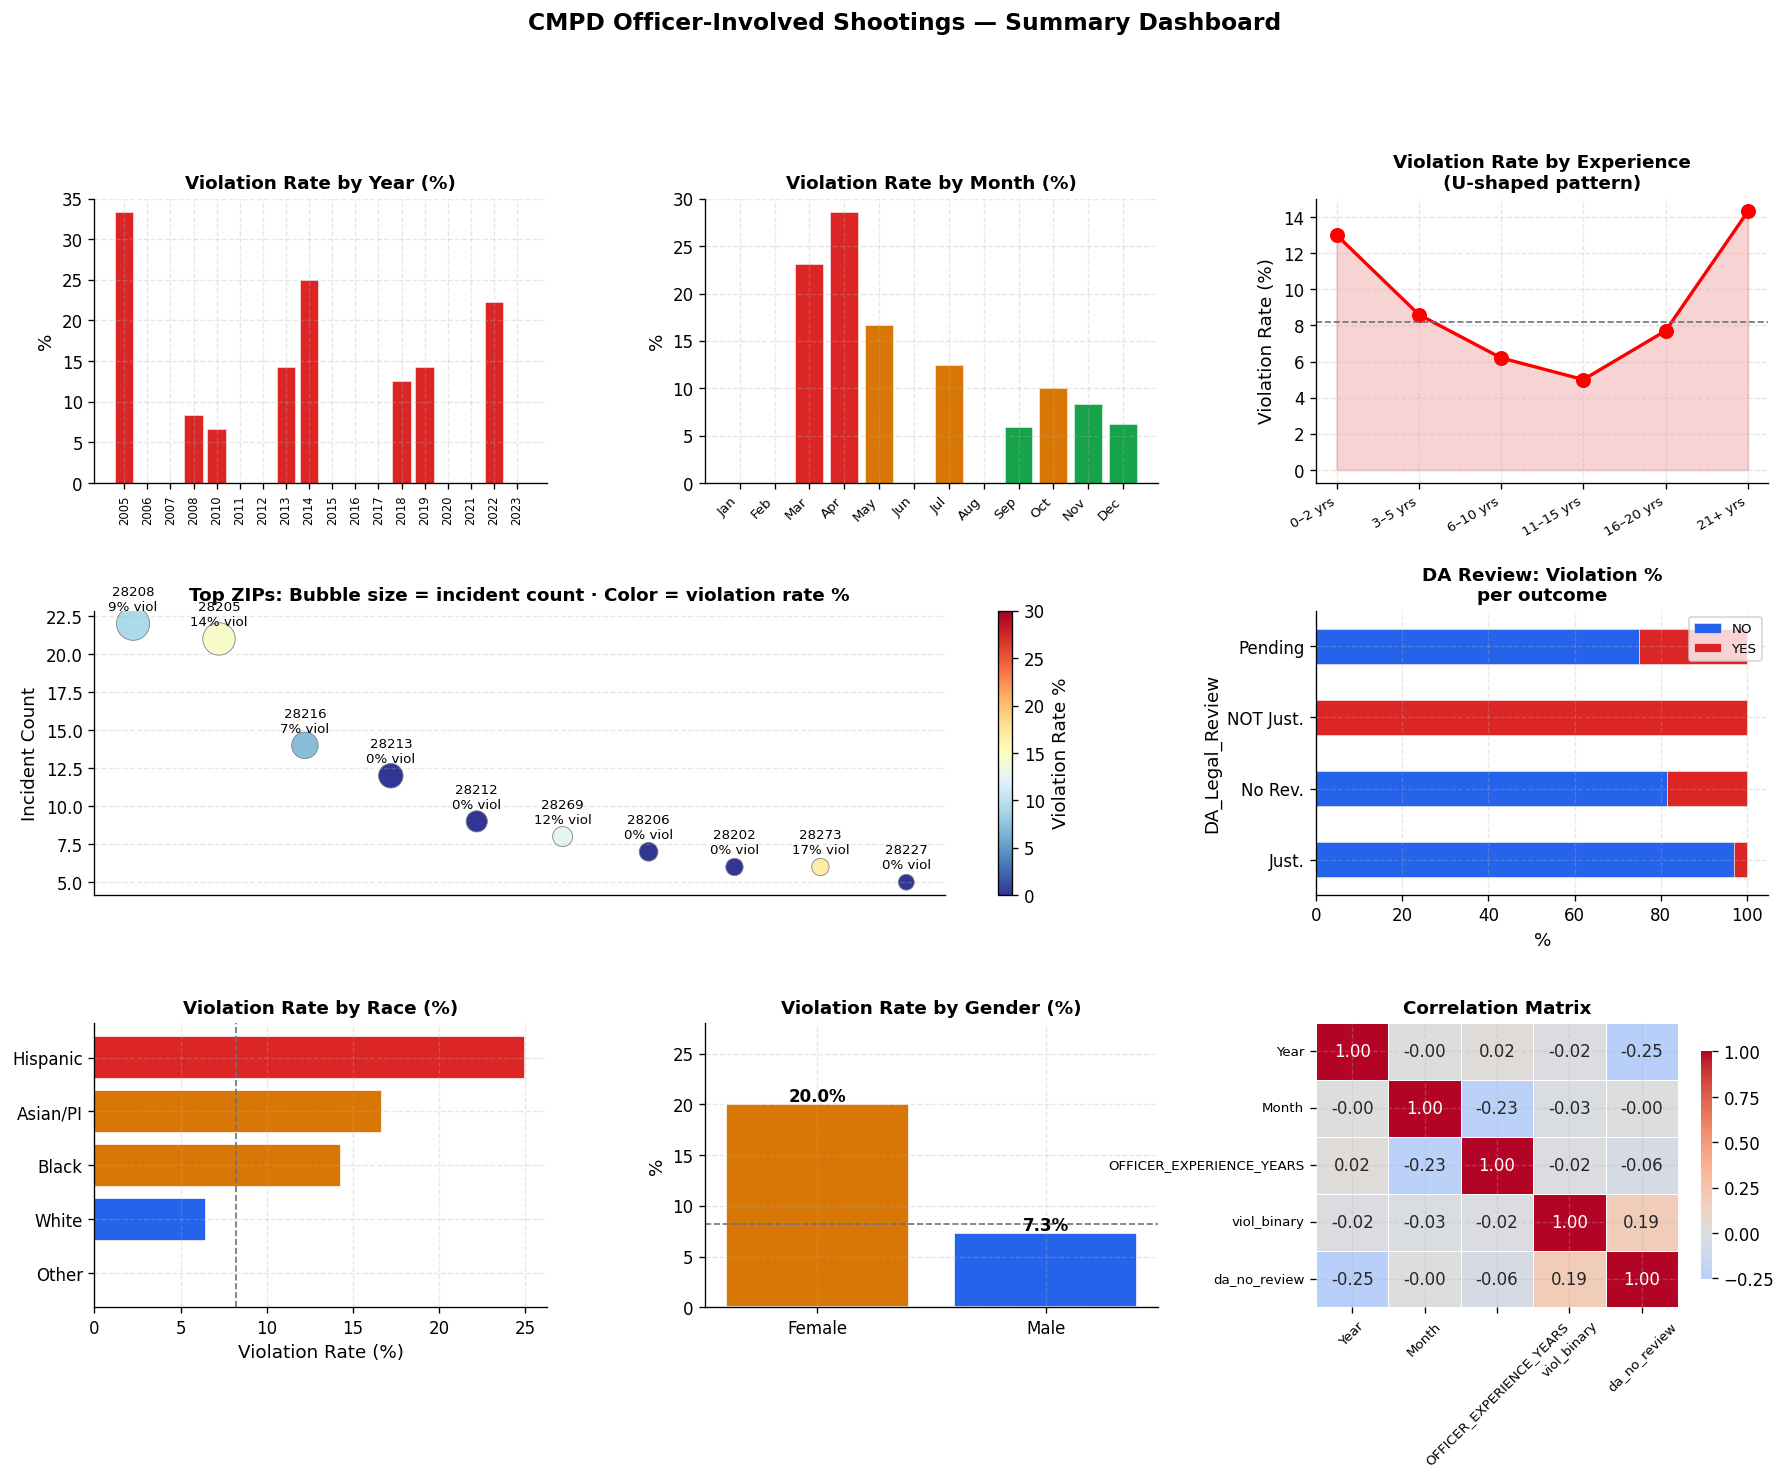

In [45]:
# Summary dashboard
fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# (A) Violations by year (top-left)
ax1 = fig.add_subplot(gs[0, 0])
yr_viol_rate = (viol_by_year / year_counts * 100).fillna(0)
ax1.bar(range(len(year_counts)), yr_viol_rate.values,
        color=[RED if v > 0 else BLUE for v in yr_viol_rate.values], edgecolor='white', linewidth=0.3)
ax1.set_xticks(range(len(year_counts)))
ax1.set_xticklabels(year_counts.index.astype(str), rotation=90, fontsize=7)
ax1.set_title('Violation Rate by Year (%)', fontsize=11)
ax1.set_ylabel('%')

# (B) Monthly violation rate (top-center)
ax2 = fig.add_subplot(gs[0, 1])
mv_rates = [month_viol_rate.get(m, 0) for m in month_order]
ax2.bar(month_order, mv_rates,
        color=[RED if r >= 20 else (AMBER if r >= 10 else GREEN) for r in mv_rates],
        edgecolor='white', linewidth=0.3)
ax2.set_title('Violation Rate by Month (%)', fontsize=11)
ax2.set_xticklabels(month_order, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('%')

# (C) Experience U-curve (top-right)
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(range(len(exp_viol)), exp_viol['rate'], 'ro-', markersize=8, linewidth=2)
ax3.fill_between(range(len(exp_viol)), exp_viol['rate'], alpha=0.2, color=RED)
ax3.set_xticks(range(len(exp_viol)))
ax3.set_xticklabels(exp_viol.index, rotation=30, ha='right', fontsize=8)
ax3.set_title('Violation Rate by Experience\n(U-shaped pattern)', fontsize=11)
ax3.set_ylabel('Violation Rate (%)')
ax3.axhline(11/134*100, color=GRAY, linestyle='--', linewidth=1)

# (D) ZIP heatmap (middle-left + center)
ax4 = fig.add_subplot(gs[1, :2])
top_zips = df.groupby('ZIP')['viol_binary'].agg(['sum','count'])
top_zips['rate'] = (top_zips['sum'] / top_zips['count'] * 100).round(1)
top_zips = top_zips[top_zips['count'] >= 3].sort_values('count', ascending=False).head(10)
scatter = ax4.scatter(range(len(top_zips)), top_zips['count'],
                      c=top_zips['rate'], cmap='RdYlBu_r', s=top_zips['count']*18,
                      edgecolors='gray', linewidths=0.5, vmin=0, vmax=30)
for i, (z, row) in enumerate(top_zips.iterrows()):
    ax4.annotate(f"{z}\n{row['rate']:.0f}% viol", (i, row['count']),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)
ax4.set_xticks([])
ax4.set_title('Top ZIPs: Bubble size = incident count · Color = violation rate %', fontsize=11)
ax4.set_ylabel('Incident Count')
plt.colorbar(scatter, ax=ax4, label='Violation Rate %')

# (E) DA review x violation (middle-right)
ax5 = fig.add_subplot(gs[1, 2])
da_summary = pd.crosstab(df_test['DA_Legal_Review'], df_test['OFFICER_POLICY_VIOLATION'])
da_summary_short = da_summary.rename(index=da_short)
da_pct = da_summary_short.div(da_summary_short.sum(axis=1), axis=0) * 100
da_pct.plot(kind='barh', stacked=True, ax=ax5,
            color=[BLUE, RED][:da_pct.shape[1]], edgecolor='white', linewidth=0.3)
ax5.set_title('DA Review: Violation %\nper outcome', fontsize=11)
ax5.set_xlabel('%')
ax5.legend(fontsize=8)

# (F) Race x violation (bottom-left)
ax6 = fig.add_subplot(gs[2, 0])
race_viol_bar = race_viol.sort_values('rate', ascending=True)
ax6.barh(race_viol_bar.index, race_viol_bar['rate'],
         color=[RED if r >= 20 else (AMBER if r >= 10 else BLUE) for r in race_viol_bar['rate']],
         edgecolor='white')
ax6.axvline(11/134*100, color=GRAY, linestyle='--', linewidth=1)
ax6.set_title('Violation Rate by Race (%)', fontsize=11)
ax6.set_xlabel('Violation Rate (%)')

# (G) Gender x violation (bottom-center)
ax7 = fig.add_subplot(gs[2, 1])
gv = df_test[df_test['OFFICER_GENDER']!='Undisclosed'].groupby('OFFICER_GENDER')['viol_binary'].agg(['sum','count'])
gv['rate'] = gv['sum'] / gv['count'] * 100
ax7.bar(gv.index, gv['rate'], color=[AMBER, BLUE], edgecolor='white')
for i, (_, row) in enumerate(gv.iterrows()):
    ax7.text(i, row['rate']+0.3, f"{row['rate']:.1f}%", ha='center', fontsize=10, fontweight='bold')
ax7.set_title('Violation Rate by Gender (%)', fontsize=11)
ax7.set_ylabel('%')
ax7.set_ylim(0, 28)
ax7.axhline(11/134*100, color=GRAY, linestyle='--', linewidth=1)

# (H) Correlation matrix (bottom-right)
ax8 = fig.add_subplot(gs[2, 2])
corr_cols = ['Year','Month','OFFICER_EXPERIENCE_YEARS','viol_binary','da_no_review']
corr_df   = model_df[corr_cols].corr()
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax8, linewidths=0.5, cbar_kws={'shrink':0.8})
ax8.set_title('Correlation Matrix', fontsize=11)
ax8.tick_params(axis='x', rotation=45, labelsize=8)
ax8.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('CMPD Officer-Involved Shootings — Summary Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('fig12_summary_dashboard.png', bbox_inches='tight')
plt.show()

## 11. EDA Findings → Actionable Recommendations

### How Analysis Connects to Recommendations

| EDA Finding | Pattern | Recommendation |
|---|---|---|
| March & April have 25–29% violation rates despite moderate volume | **Temporal risk window** | Increase pre-shift training in Feb–Mar; schedule mandatory scenario-based debrief after spring incidents |
| 2016 incident spike (×4 vs prior year) with 0 violations | **Volume spike anomaly** | Audit 2016 classification methodology; verify no reporting changes skewed outcomes |
| Q3 has highest total incidents (Jul–Sep) | **Seasonal peak** | Surge patrol staffing in Q3; community cooling-center programs may reduce tension incidents |
| ZIP 28208 (n=22) & 28205 (n=21) = 30% of all incidents | **Geographic hotspot** | Reallocate patrol coverage to these two ZIPs; assign community liaison officers |
| Somerdale Ln & Watson Dr each appear ×8 | **Street-level repeat locations** | Develop site-specific engagement protocols; track repeat-call history per address |
| "No DA Review" cases: 18.5% violation rate vs 2.9% with DA review | **Accountability gap** | Mandate DA review for ALL incidents; create escalation protocol when review is skipped |
| Experience: U-shaped (rookies 13%, veterans 21+ yrs 14.3%) | **Experience curve** | Early intervention for both recruits (supervision pairing) AND veterans (refresher training) |
| Pearson r (experience, violation) = −0.011 | **Experience not linear predictor** | Years-of-service alone insufficient for risk screening — consider complaint history, prior incidents |
| Only 1 incident "not legally justified" in 18 years | **Review outcome skew** | Independent audit of justification criteria; compare to peer departments |
| 2009 data completely missing | **Data integrity gap** | Recover 2009 records before any trend modeling; document data provenance |

---

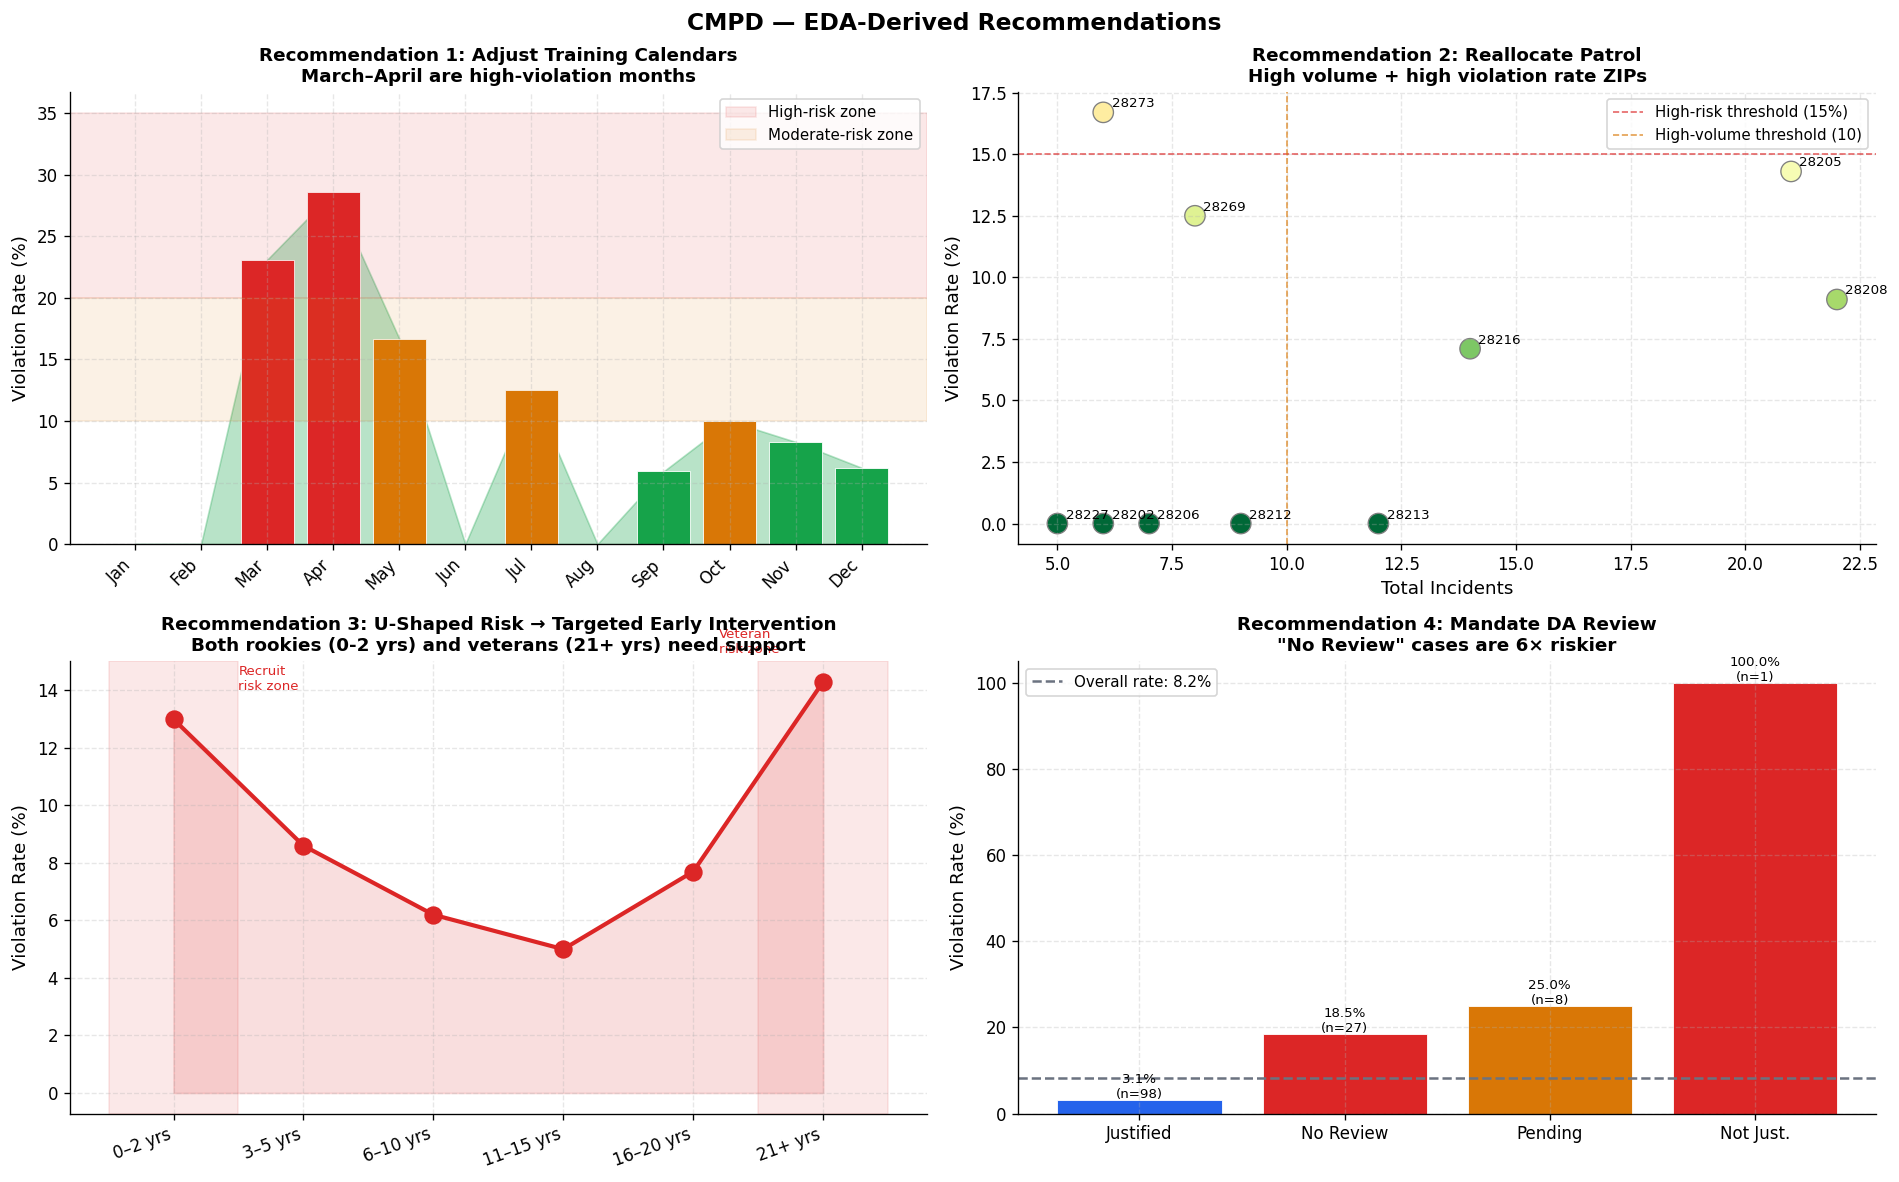

In [46]:
# Final recommendation visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (1) Temporal recommendation: Monthly violation rate trend
mv_df_plot = pd.DataFrame({'Month': month_order, 'Violation_Rate': mv_rates})
axes[0,0].fill_between(range(12), mv_rates, alpha=0.3,
                        color=[RED if r>=20 else (AMBER if r>=10 else GREEN) for r in mv_rates][0])
axes[0,0].bar(range(12), mv_rates,
              color=[RED if r>=20 else (AMBER if r>=10 else GREEN) for r in mv_rates],
              edgecolor='white', linewidth=0.5)
axes[0,0].set_xticks(range(12))
axes[0,0].set_xticklabels(month_order, rotation=45, ha='right')
axes[0,0].set_title('Recommendation 1: Adjust Training Calendars\nMarch–April are high-violation months', fontsize=11)
axes[0,0].set_ylabel('Violation Rate (%)')
axes[0,0].axhspan(20, 35, alpha=0.1, color=RED, label='High-risk zone')
axes[0,0].axhspan(10, 20, alpha=0.1, color=AMBER, label='Moderate-risk zone')
axes[0,0].legend(fontsize=9)

# (2) Geographic recommendation: ZIP violation rates
top_zip_plot = top_zips.copy()
axes[0,1].scatter(top_zip_plot['count'], top_zip_plot['rate'],
                  c=top_zip_plot['rate'], cmap='RdYlGn_r',
                  s=150, edgecolors='gray', linewidths=0.8, vmin=0, vmax=30)
for z, row in top_zip_plot.iterrows():
    axes[0,1].annotate(z, (row['count'], row['rate']),
                       textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[0,1].axhline(15, color=RED, linestyle='--', linewidth=1, alpha=0.7, label='High-risk threshold (15%)')
axes[0,1].axvline(10, color=AMBER, linestyle='--', linewidth=1, alpha=0.7, label='High-volume threshold (10)')
axes[0,1].set_xlabel('Total Incidents')
axes[0,1].set_ylabel('Violation Rate (%)')
axes[0,1].set_title('Recommendation 2: Reallocate Patrol\nHigh volume + high violation rate ZIPs', fontsize=11)
axes[0,1].legend(fontsize=9)

# (3) Officer experience recommendation
axes[1,0].plot(range(len(exp_viol)), exp_viol['rate'], 'o-',
               color=RED, markersize=10, linewidth=2.5)
axes[1,0].fill_between(range(len(exp_viol)), exp_viol['rate'], alpha=0.15, color=RED)
axes[1,0].set_xticks(range(len(exp_viol)))
axes[1,0].set_xticklabels(exp_viol.index, rotation=20, ha='right')
axes[1,0].set_title('Recommendation 3: U-Shaped Risk → Targeted Early Intervention\nBoth rookies (0-2 yrs) and veterans (21+ yrs) need support', fontsize=11)
axes[1,0].set_ylabel('Violation Rate (%)')
axes[1,0].axvspan(-0.5, 0.5, alpha=0.1, color=RED)
axes[1,0].axvspan(4.5, 5.5, alpha=0.1, color=RED)
axes[1,0].annotate('Recruit\nrisk zone', xy=(0, exp_viol['rate'].iloc[0]),
                   xytext=(0.5, exp_viol['rate'].iloc[0]+1), fontsize=8, color=RED)
axes[1,0].annotate('Veteran\nrisk zone', xy=(5, exp_viol['rate'].iloc[-1]),
                   xytext=(4.2, exp_viol['rate'].iloc[-1]+1), fontsize=8, color=RED)

# (4) DA review recommendation
da_viol_summary = pd.DataFrame({
    'Outcome': ['Legally Justified', 'No DA Review', 'Pending Review', 'Not Justified'],
    'ViolRate': [3/98*100, 5/27*100, 2/8*100, 1/1*100],
    'n': [98, 27, 8, 1]
})
colors_da_rec = [BLUE, RED, AMBER, RED]
bars_da = axes[1,1].bar(da_viol_summary['Outcome'], da_viol_summary['ViolRate'],
                        color=colors_da_rec, edgecolor='white', linewidth=0.5)
for bar, row in zip(bars_da, da_viol_summary.itertuples()):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{row.ViolRate:.1f}%\n(n={row.n})', ha='center', fontsize=8)
axes[1,1].set_title('Recommendation 4: Mandate DA Review\n"No Review" cases are 6× riskier', fontsize=11)
axes[1,1].set_ylabel('Violation Rate (%)')
axes[1,1].set_xticklabels(['Justified','No Review','Pending','Not Just.'], fontsize=10)
axes[1,1].axhline(11/134*100, color=GRAY, linestyle='--', linewidth=1.5,
                  label=f'Overall rate: {11/134*100:.1f}%')
axes[1,1].legend(fontsize=9)

plt.suptitle('CMPD — EDA-Derived Recommendations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_recommendations.png', bbox_inches='tight')
plt.show()

## 12. Final Summary

### EDA Summary Statistics


In [47]:
#Final summary printout
print("=" * 65)
print("  CMPD OFFICER-INVOLVED SHOOTINGS — EDA SUMMARY")
print("=" * 65)
print(f"  Total incidents analyzed        : {len(df)}")
print(f"  Date range                      : 2005–2023 (2009 missing)")
print(f"  Policy violations recorded      : 11 ({11/134*100:.1f}% of known records)")
print(f"  DA-justified rate               : {105/141*100:.1f}%")
print(f"  Only 1 shooting ever 'not justified' in 18 years")
print()
print("  TEMPORAL:")
print(f"  • Peak year: 2016 (n=20, 0 violations)")
print(f"  • Highest violation months: April (28.6%), March (25%)")
print(f"  • Q3 (Jul–Sep) has most incidents: 43")
print()
print("  GEOGRAPHIC:")
print(f"  • Top ZIPs: 28208 (n=22) and 28205 (n=21)")
print(f"  • Hotspot streets: Somerdale Ln & Watson Dr (×8 each)")
print(f"  • ZIP 28214 and 28217 have highest violation rates (25–33%)")
print()
print("  OFFICER PROFILE:")
print(f"  • White officers: 80% of incidents, 6.5% violation rate")
print(f"  • Female violation rate: 20% vs male 6.9% (small n=10)")
print(f"  • Experience U-curve: 0-2 yrs (13%) and 21+ yrs (14.3%) elevated")
print(f"  • Pearson r(experience, violation) = -0.011 → no linear effect")
print()
print("  ACCOUNTABILITY:")
print(f"  • No DA Review cases: 18.5% violation rate")
print(f"  • DA-reviewed cases:   2.9% violation rate (6× difference)")
print()
print("  DATA QUALITY FLAGS:")
print(f"  • 7 null values on OFFICER_POLICY_VIOLATION (5%)")
print(f"  • Shape column 100% null (dropped)")
print(f"  • 2021-22: 8 pending DA reviews (outcomes incomplete)")
print(f"  • 2009: entire year missing from dataset")
print("=" * 65)

  CMPD OFFICER-INVOLVED SHOOTINGS — EDA SUMMARY
  Total incidents analyzed        : 141
  Date range                      : 2005–2023 (2009 missing)
  Policy violations recorded      : 11 (8.2% of known records)
  DA-justified rate               : 74.5%
  Only 1 shooting ever 'not justified' in 18 years

  TEMPORAL:
  • Peak year: 2016 (n=20, 0 violations)
  • Highest violation months: April (28.6%), March (25%)
  • Q3 (Jul–Sep) has most incidents: 43

  GEOGRAPHIC:
  • Top ZIPs: 28208 (n=22) and 28205 (n=21)
  • Hotspot streets: Somerdale Ln & Watson Dr (×8 each)
  • ZIP 28214 and 28217 have highest violation rates (25–33%)

  OFFICER PROFILE:
  • White officers: 80% of incidents, 6.5% violation rate
  • Female violation rate: 20% vs male 6.9% (small n=10)
  • Experience U-curve: 0-2 yrs (13%) and 21+ yrs (14.3%) elevated
  • Pearson r(experience, violation) = -0.011 → no linear effect

  ACCOUNTABILITY:
  • No DA Review cases: 18.5% violation rate
  • DA-reviewed cases:   2.9% violat

---
## Advice Delivered

| # | Advice | Evidence | Value |
|---|---|---|---|
| 1 | **Adjust patrol schedules** — increase staffing in Q3 and early spring | Q3 peak (n=43); March/April violation spike | Reduced harm, targeted deployment |
| 2 | **Reallocate patrol coverage** to ZIPs 28208 and 28205; site-specific protocols for Somerdale Ln and Watson Dr | 30% of all incidents in 2 ZIPs; ×8 repeat at two streets | Stronger community trust |
| 3 | **Mandate DA review** for all incidents — close the accountability gap | No-review cases 6× more likely to involve violations | Better accountability and transparency |
| 4 | **Early intervention for both ends of career** — recruit supervision AND veteran refresher training | U-shaped violation curve: 0-2 yrs (13%), 21+ yrs (14%) | Evidence-based training, reduced harm |
| 5 | **Audit 2009 data gap and 2016 classification spike** | Complete year missing; 2016 doubled with uniform "justified" outcome | Evidence-based policy decisions |
| 6 | **Strengthen reporting**: expand variables to include call type, body cam status, subject armed/unarmed | Current dataset lacks these key predictors | Improved model accuracy for future risk profiling |

> **Overall managerial answer:** CMPD can reduce officer-involved shootings by concentrating resources geographically (ZIPs 28208/28205), adjusting schedules to cover spring/Q3 risk windows, mandating DA accountability review, and targeting early intervention at both career extremes — all while expanding data collection to enable more precise future modeling.
